# MINI PROJECT 1
### TOPIC : SPATIAL ANALYSIS OF SOCIOECONOMIC VULNERABILITY AND ASTHMA PREVALENCE IN MICHIGAN 

### PROBLEM STATEMENT
Asthma is a chronic inflammatory respiratory disease that affects people of all ages and remains one of the most common chronic conditions globally. While environmental factors such as air pollution, damp housing conditions, dust and pest exposure are known to increase asthma risk, these factors alone do not fully explain the spatial variations in asthma outcomes observed across communities. Numerous studies have highlighted the role of social determinants of health (socioeconomic conditions) in shaping health outcomes such as asthma. These conditions vary widely across communities and reflect underlying geographic and demographic differences. Examining how these conditions are distributed spatially is therefore important for identifying communities that may experience greater health vulnerability.

This project explores how selected socioeconomic conditions influence variations in asthma prevalence across Michigan. It focuses on four key measures: poverty rate, unemployment rate, housing cost burden and median household income. The main objective is to examine the spatial patterns of these indicators and assess their relationship with asthma prevalence. Identifying these patterns will reveal communities facing structural disadvantages in employment opportunities, housing affordability and income that may contribute to disparities in asthma outcomes.

### DATA SOURCES : MiEJScreen dataset & CDC PLACES dataset
The project used data from Michigan’s Environmental Justice Screening tool (MiEJScreen) and CDC PLACES dataset. The MiEJScreen is an interactive mapping tool developed to identify communities that may be more vulnerable to environmental and socioeconomic stressors. The dataset contains several indicators at the census tract level for the state of Michigan.
Asthma prevalence data from 2020-2023 was obtained from the CDC PLACES dataset. This dataset provides census-tract–level estimates of crude asthma prevalence using small-area estimation methods that integrate Behavioral Risk Factor Surveillance System data, Census population data and American Community Survey data.

### STEPS
1.Load the MiEJScreen dataset to check the column names and missing values.

2.Clean and select the relevant variables [poverty rate, unemployment rate, housing cost burden, median household income]

3.Create exploratory charts (histograms) for the variables.

4.Load Michigan geographic boundary dataset (census tract level).

5.Join socioeconomic data to geographic boundaries using a common identifier.

6.Create choropleth maps for the variables to visualize their spatial distribution.

7.Load the CDC PLACES asthma dataset (2020–2023) and create choropleth maps for each year.

8.Calculate the average asthma prevalence from 2020–2023 for each tract. 

9.Conduct Spearman correlation analysis to evaluate the relationship between asthma prevalence and each socioeconomic variable.

10.Perform multiple linear regression to assess the combined influence of socioeconomic factors on asthma prevalence.

11.Create a dual burden variable to identify census tracts experiencing both high asthma prevalence and high socioeconomic vulnerability.

12.Create maps of dual burden and cumulative vulnerability score to visually identify spatial patterns of risk.

13.Publish the GeoDataFrame to ArcGIS Online using the ArcGIS Python API as a hosted feature layer.

### WHY THIS PROJECT?
I chose this project because it directly relates to my thesis on "Spatio-temporal trends of Asthma in Michigan". This project specifically addresses the third research question of the thesis: How do socioeconomic conditions influence variations in asthma outcomes across Michigan? The analysis investigates whether communities with higher asthma prevalence also experience greater socioeconomic vulnerability. This is particularly important because indicators like poverty, unemployment, housing instability are widely recognized social conditions that influence respiratory health risks like asthma.

### PART A: SOCIOECONOMIC VULNERABILITY

In [1]:
#Loading the dataset
import pandas as pd 
df = pd.read_csv('SocioEconomic_MIEJscreen.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 77 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   OBJECTID_12                                                                                          2767 non-null   int64  
 1   OBJECTID                                                                                             2767 non-null   int64  
 2   GEOID                                                                                                2767 non-null   int64  
 3   ALAND                                                                                                2767 non-null   int64  
 4   AWATER                                                                                               2767 no

In [2]:
df.columns

Index(['OBJECTID_12', 'OBJECTID', 'GEOID', 'ALAND', 'AWATER', 'NAME', 'State',
       'County', 'B01001_001', 'Shape_Leng', 'GEOID.1', 'TRACT',
       'TpopEducation', 'Education', 'EducationP', 'EducationPL',
       'PopGTE5LingIsol', 'TPopGTE5', 'LingIsolP', 'LingIsolPL', 'TPOP',
       'POVRateLT2XE', 'POVRateLT2X2P', 'POVRateLT2X2PL', 'PopCivilLabFor',
       'Unemployed', 'UnemployedP', 'UnemployedPL', 'TPopH', 'HousingE',
       'HousingEP', 'HousingEP100', 'HousingEP100PL', 'TPop2', 'WhiteAlone',
       'WhiteAloneP', 'Minorities', 'MinoritiesP', 'MinoritiesCHECK',
       'MinoritiesPL', 'Tpop#1', 'MalesLT5', 'FemalesLT5', 'TotalLT5',
       'TotalLT5P', 'TotalLT5PL', 'PopGTE65', 'PopGTE65P', 'PopGTE65PL',
       'SOCECONAve', 'SOCECONAvePLPL', 'Total Population', 'ALANDSQMi',
       'PopDenMiSq2', 'Percent Unemployed',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)',
       'White alone, Not Hispanic or Latino Populat

In [3]:
#The dataset has so many columns, I need to narrow down the columns to the ones that are relevant to my analysis. 
df_trimmed = df[[ 'GEOID', 'County', 'POVRateLT2X2P','UnemployedP','HousingEP','HousingEP100','Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)']]
df_trimmed.head()

,GEOID,County,POVRateLT2X2P,UnemployedP,HousingEP,HousingEP100,Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)
0,26001970600,Alcona County,39.940609,16.2,0.226006,22.600619,39950.0
1,26005030200,Allegan County,11.920530,3.1,0.190359,19.035948,86007.0
2,26005030300,Allegan County,15.899151,3.4,0.146535,14.653540,73689.0
3,26005030401,Allegan County,21.892345,5.3,0.185641,18.564062,71813.0
4,26005030402,Allegan County,16.964618,6.6,0.196178,19.617763,76431.0


In [4]:
columns = {'GEOID': 'GEOID', 'County': 'County', 'POVRateLT2X2P': 'Poverty Rate', 'UnemployedP': 'Unemployment Rate', 'HousingEP': 'Housing Burdened', 'HousingEP100': 'Housing Burdened 100%', 'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)': 'Median Household Income'}
df_cleaned = df_trimmed.rename(columns=columns)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   int64  
 1   County                   2767 non-null   object 
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 151.4+ KB


In [5]:
df_cleaned.describe()

,GEOID,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
count,2.767000e+03,2767.000000,2746.000000,2738.000000,2767.000000,2728.000000
mean,2.610888e+10,34.286378,13.155717,0.298443,29.531530,59434.423387
std,4.710726e+07,19.803617,8.617299,0.119485,12.268216,27736.695064
min,2.600100e+10,0.000000,0.000000,0.000000,0.000000,7859.000000
25%,2.607501e+10,18.903917,7.400000,0.214429,21.296748,40924.500000
50%,2.612100e+10,30.673165,10.600000,0.268940,26.791621,54765.500000
75%,2.616140e+10,46.120103,16.000000,0.361619,35.909091,72339.000000
max,2.616538e+10,100.000000,66.700000,1.000000,100.000000,215417.000000


From the table, the average poverty rate is 34.29% , the average unemployment rate is 13.16%, and the average share of housing cost-burdened households is 0.298 (about 29.84% of households spending more than 30% of their income on housing). The mean median household income across tracts is $59,434 (inflation-adjusted). 

### CHARTS

#### Please Note: The charts below represent the distribution of the selected socioeconomic indicators across all census tracts in Michigan, not only disadvantaged communities.

### Poverty Rate :
This variable represents the percentage of the population living below 200 percent of the federal poverty level.

<Axes: title={'center': 'Distribution of Poverty Rates in Michigan'}, xlabel='Poverty Rate', ylabel='Frequency'>

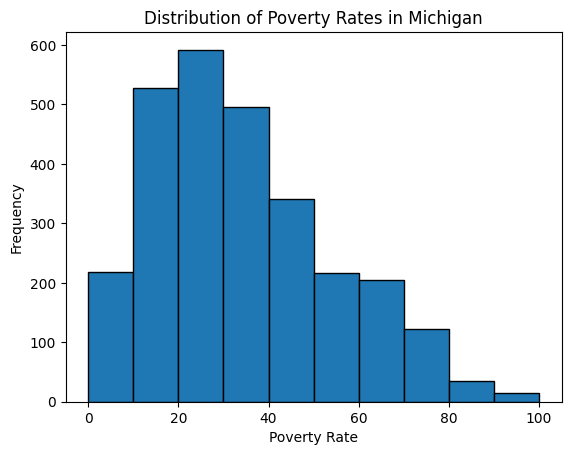

In [5]:
#Great. Now we have our dataset cleaned and ready for analysis.
import matplotlib as plot
df_cleaned['Poverty Rate'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Poverty Rates in Michigan',xlabel ='Poverty Rate', ylabel = 'Frequency')

<Axes: title={'center': 'Distribution of Poverty Rates in Michigan'}, xlabel='Poverty Rate', ylabel='Frequency'>

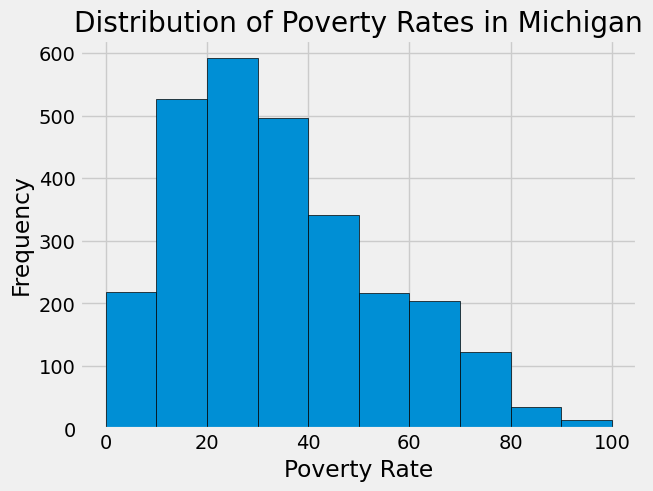

In [7]:
#Let me try another design for the histogram.
import matplotlib.pyplot as plt
figsize = (8, 10)
plt.style.use('fivethirtyeight')
df_cleaned['Poverty Rate'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Poverty Rates in Michigan',xlabel ='Poverty Rate', ylabel = 'Frequency')

The histogram shows that most census tracts cluster in the low-to-moderate poverty range (roughly 10–40%), with the highest frequencies around 20–30%. The distribution is right-skewed, indicating that while some tracts experience moderate poverty rates, a small number face extreme levels (above 60%). This pattern suggests substantial spatial inequality.

### Unemployment Rate:
The unemployment rate represents the percentage of the civilian labor force aged 16 and older that is currently unemployed.

<Axes: title={'center': 'Distribution of Unemployment Rates in Michigan'}, xlabel='Unemployment Rate', ylabel='Frequency'>

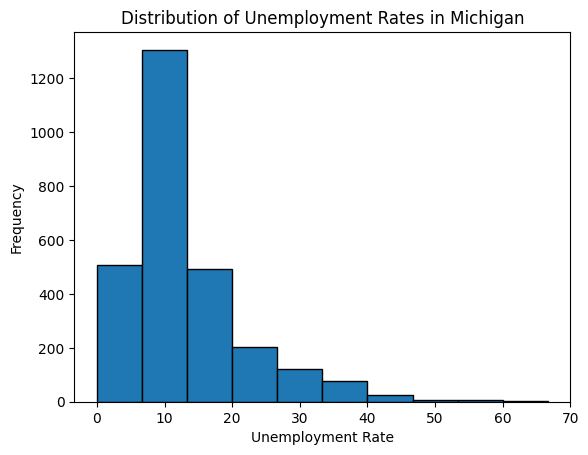

In [6]:
figsize = (8, 10)
df_cleaned['Unemployment Rate'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Unemployment Rates in Michigan',xlabel ='Unemployment Rate', ylabel = 'Frequency')

The histogram indicates that most census tracts have relatively low unemployment rates, with a clear peak around 10%. The distribution is strongly right-skewed, showing that only a small number of tracts experience very high unemployment (above 30%).

### Housing Cost Burden:
Housing cost burden measures the percentage of households that spend more than 30 percent of their income on housing costs.

<Axes: title={'center': 'Distribution of Housing Burdened Rates in Michigan'}, xlabel='Housing Burdened Rate', ylabel='Frequency'>

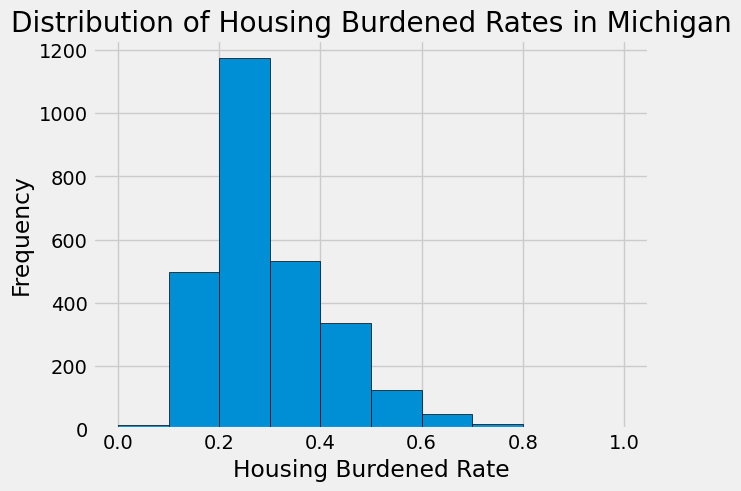

In [9]:
df_cleaned['Housing Burdened'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Housing Burdened Rates in Michigan',xlabel ='Housing Burdened Rate', ylabel = 'Frequency')

<Axes: title={'center': 'Distribution of Housing Burdened [100% Rates] in Michigan'}, xlabel='Housing Burdened Rate', ylabel='Frequency'>

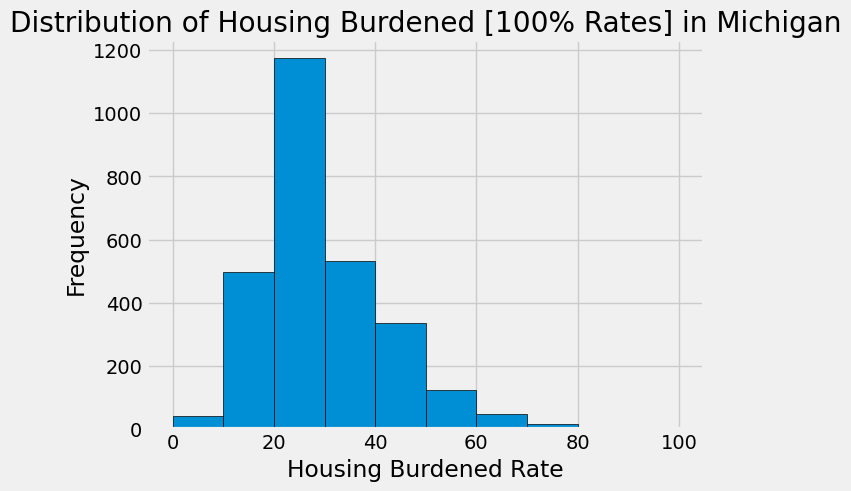

In [10]:
#The variable 'Housing Burdened 100%' is the percentage of households that are housing burdened at the 100% level.This will be easier to interpret. 
df_cleaned['Housing Burdened 100%'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Housing Burdened [100% Rates] in Michigan',xlabel ='Housing Burdened Rate', ylabel = 'Frequency')

The histogram shows that most census tracts in Michigan have housing-burdened rates clustered between about 10% and 40%, with a peak around 30%. The distribution is right-skewed, indicating that fewer tracts experience very high levels of housing cost burden (above 50%).

### Median Household Income:
Median household income represents the inflation-adjusted income level (adjusted to the final year of the five-year period).

<Axes: title={'center': 'Distribution of Median Household Income in Michigan'}, xlabel='Median Household Income $', ylabel='Frequency'>

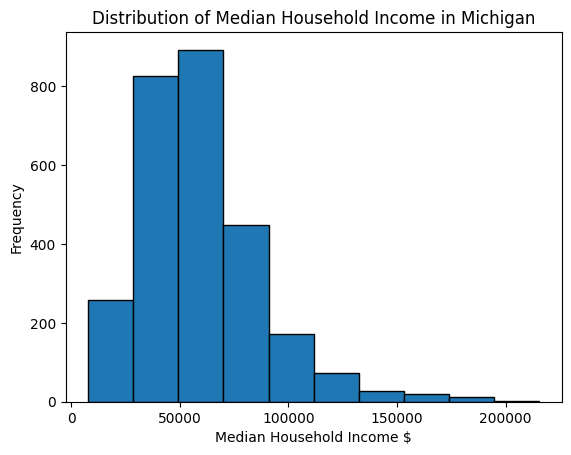

In [7]:
df_cleaned['Median Household Income'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Median Household Income in Michigan',xlabel ='Median Household Income $', ylabel = 'Frequency')

The histogram shows that most census tracts in Michigan have median household incomes concentrated between roughly $40,000 and $80,000 with a peak around $50,000. The distribution is right-skewed, indicating that a smaller number of tracts have very high incomes while fewer tracts fall at the very low-income end.

## MAPS

In [8]:
import geopandas as gpd
import pandas as pd

In [9]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   int64  
 1   County                   2767 non-null   object 
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 151.4+ KB


In [14]:
df_cleaned.head()

,GEOID,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
0,26001970600,Alcona County,39.940609,16.2,0.226006,22.600619,39950.0
1,26005030200,Allegan County,11.920530,3.1,0.190359,19.035948,86007.0
2,26005030300,Allegan County,15.899151,3.4,0.146535,14.653540,73689.0
3,26005030401,Allegan County,21.892345,5.3,0.185641,18.564062,71813.0
4,26005030402,Allegan County,16.964618,6.6,0.196178,19.617763,76431.0


In [10]:
df_cleaned.tail()

,GEOID,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
2762,26079950400,Kalkaska County,42.007129,14.3,0.277437,27.743695,47183.0
2763,26079950602,Kalkaska County,37.723859,15.4,0.233838,23.383769,50066.0
2764,26135970300,Oscoda County,47.358370,12.2,0.330163,33.016304,37788.0
2765,26135970400,Oscoda County,42.467089,16.4,0.312277,31.227652,38017.0
2766,26135970500,Oscoda County,38.256344,13.3,0.203857,20.385675,43938.0


### Load the Michigan census tract boundaries using geodatasets/pygris

In [11]:
import geopandas as gpd
import geodatasets as gds


In [12]:
import pygris
michigan_tracts = pygris.tracts(state = 'MI', year = 2010)

Using FIPS code '26' for input 'MI'


Census tract boundaries from the 2010 Census were used because the MIEJScreen dataset (published in 2021) is based on 2010 tracts.

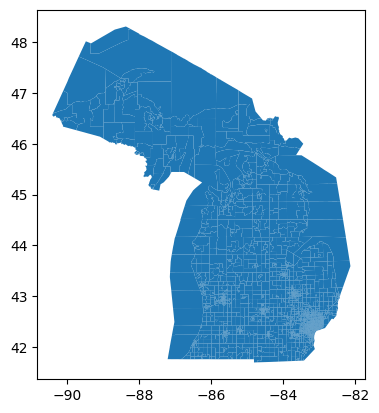

In [13]:
michigan_tracts.plot();

In [14]:
michigan_tracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2813 entries, 0 to 2812
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   STATEFP10   2813 non-null   object  
 1   COUNTYFP10  2813 non-null   object  
 2   TRACTCE10   2813 non-null   object  
 3   GEOID10     2813 non-null   object  
 4   NAME10      2813 non-null   object  
 5   NAMELSAD10  2813 non-null   object  
 6   MTFCC10     2813 non-null   object  
 7   FUNCSTAT10  2813 non-null   object  
 8   ALAND10     2813 non-null   int64   
 9   AWATER10    2813 non-null   int64   
 10  INTPTLAT10  2813 non-null   object  
 11  INTPTLON10  2813 non-null   object  
 12  geometry    2813 non-null   geometry
dtypes: geometry(1), int64(2), object(10)
memory usage: 285.8+ KB


In [15]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   int64  
 1   County                   2767 non-null   object 
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 151.4+ KB


In [23]:
#the GEOID column in the michigan_tracts dataset is a string, but the GEOID column in the df_cleaned dataset is an integer. I need to convert the GEOID column in the df_cleaned dataset to a string so that I can merge the two datasets.
df_cleaned.head()

,GEOID,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
0,26001970600,Alcona County,39.940609,16.2,0.226006,22.600619,39950.0
1,26005030200,Allegan County,11.920530,3.1,0.190359,19.035948,86007.0
2,26005030300,Allegan County,15.899151,3.4,0.146535,14.653540,73689.0
3,26005030401,Allegan County,21.892345,5.3,0.185641,18.564062,71813.0
4,26005030402,Allegan County,16.964618,6.6,0.196178,19.617763,76431.0


In [24]:
michigan_tracts.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,+43.5849689,-084.2539377,"POLYGON ((-84.27849 43.60846, -84.27839 43.607..."
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,+43.6170755,-084.1920233,"POLYGON ((-84.20713 43.61134, -84.20744 43.611..."
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,+43.6340278,-084.2016894,"POLYGON ((-84.19284 43.64106, -84.18922 43.641..."
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,+43.6475643,-084.2215974,"POLYGON ((-84.20688 43.65404, -84.20431 43.652..."
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,+43.6464585,-084.2688725,"POLYGON ((-84.28999 43.65613, -84.28452 43.656..."


In [16]:
# Need to change the column name (GEOID10) in the michigan_tracts dataset to match the column name in the df_cleaned dataset.
michigan_tracts = michigan_tracts.rename(columns={'GEOID10': 'GEOID'})
michigan_tracts.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,+43.5849689,-084.2539377,"POLYGON ((-84.27849 43.60846, -84.27839 43.607..."
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,+43.6170755,-084.1920233,"POLYGON ((-84.20713 43.61134, -84.20744 43.611..."
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,+43.6340278,-084.2016894,"POLYGON ((-84.19284 43.64106, -84.18922 43.641..."
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,+43.6475643,-084.2215974,"POLYGON ((-84.20688 43.65404, -84.20431 43.652..."
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,+43.6464585,-084.2688725,"POLYGON ((-84.28999 43.65613, -84.28452 43.656..."


In [17]:
# Let's change the integer GEOID column in df_cleaned to a string so that we can merge the two datasets.
df_format = df_cleaned.copy()
df_format['GEOID'] = df_format['GEOID'].astype(str)
df_format.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   object 
 1   County                   2767 non-null   object 
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), object(2)
memory usage: 151.4+ KB


In [18]:
# now we can merge the two datasets.
df_merged = michigan_tracts.merge(df_format, on = 'GEOID')
df_merged.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,+43.5849689,-084.2539377,"POLYGON ((-84.27849 43.60846, -84.27839 43.607...",Midland County,12.105799,9.8,0.195291,19.529086,70959.0
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,+43.6170755,-084.1920233,"POLYGON ((-84.20713 43.61134, -84.20744 43.611...",Midland County,26.971736,9.6,0.204348,20.434783,54821.0
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,+43.6340278,-084.2016894,"POLYGON ((-84.19284 43.64106, -84.18922 43.641...",Midland County,11.159530,6.4,0.134070,13.407016,76780.0
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,+43.6475643,-084.2215974,"POLYGON ((-84.20688 43.65404, -84.20431 43.652...",Midland County,17.370311,4.0,0.193390,19.339005,91200.0
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,+43.6464585,-084.2688725,"POLYGON ((-84.28999 43.65613, -84.28452 43.656...",Midland County,21.052632,7.2,0.273676,27.367607,69920.0


In [28]:
df_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   STATEFP10                2767 non-null   object  
 1   COUNTYFP10               2767 non-null   object  
 2   TRACTCE10                2767 non-null   object  
 3   GEOID                    2767 non-null   object  
 4   NAME10                   2767 non-null   object  
 5   NAMELSAD10               2767 non-null   object  
 6   MTFCC10                  2767 non-null   object  
 7   FUNCSTAT10               2767 non-null   object  
 8   ALAND10                  2767 non-null   int64   
 9   AWATER10                 2767 non-null   int64   
 10  INTPTLAT10               2767 non-null   object  
 11  INTPTLON10               2767 non-null   object  
 12  geometry                 2767 non-null   geometry
 13  County                   2767 non-null   object  
 14  

### Choropleth Map: Poverty Rate

<Axes: >

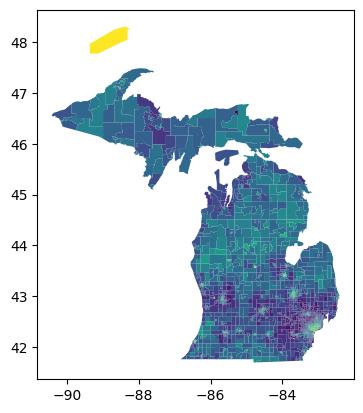

In [19]:
#Now we can create our maps.
df_merged.plot(column ='Poverty Rate')

I want to use different classification schemes.

<Axes: >

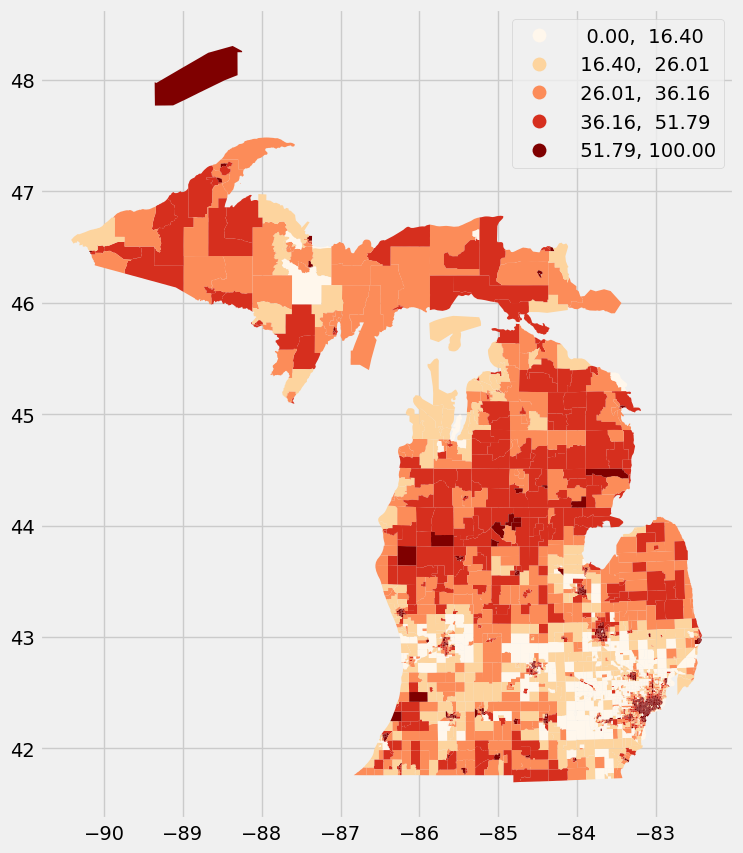

In [31]:
df_merged.plot(column='Poverty Rate', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

This map shows the share of people living below 200% of the federal poverty level across Michigan. Lighter areas indicate lower poverty rates (about 0–16.4%) and darker reds indicate higher rates (about 51.8–100%). Higher concentrations appear across parts of the Upper Peninsula and the northern/central Lower Peninsula (including parts of Southeast Michigan). Many tracts in the southern Lower Peninsula fall into the lower-to-moderate ranges.

### Unemployment Rate

<Axes: >

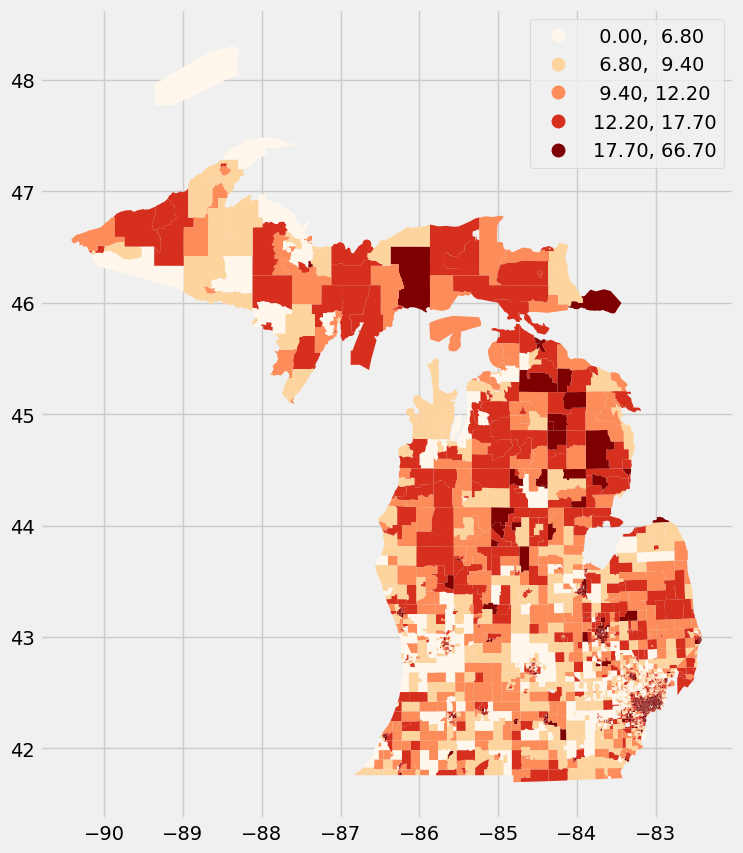

In [32]:
df_merged.plot(column='Unemployment Rate', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

This map shows unemployment rate across Michigan (the percent of the civilian labor force age 16+ that is unemployed). Lighter areas indicate lower unemployment and darker reds indicate higher unemployment. Higher unemployment rates appear across parts of the Upper Peninsula and sections of the northern/central Lower Peninsula. Additional clusters appear in  the southeast while many tracts in the southern Lower Peninsula fall into the lower to moderate categories.

### Housing Burden

<Axes: >

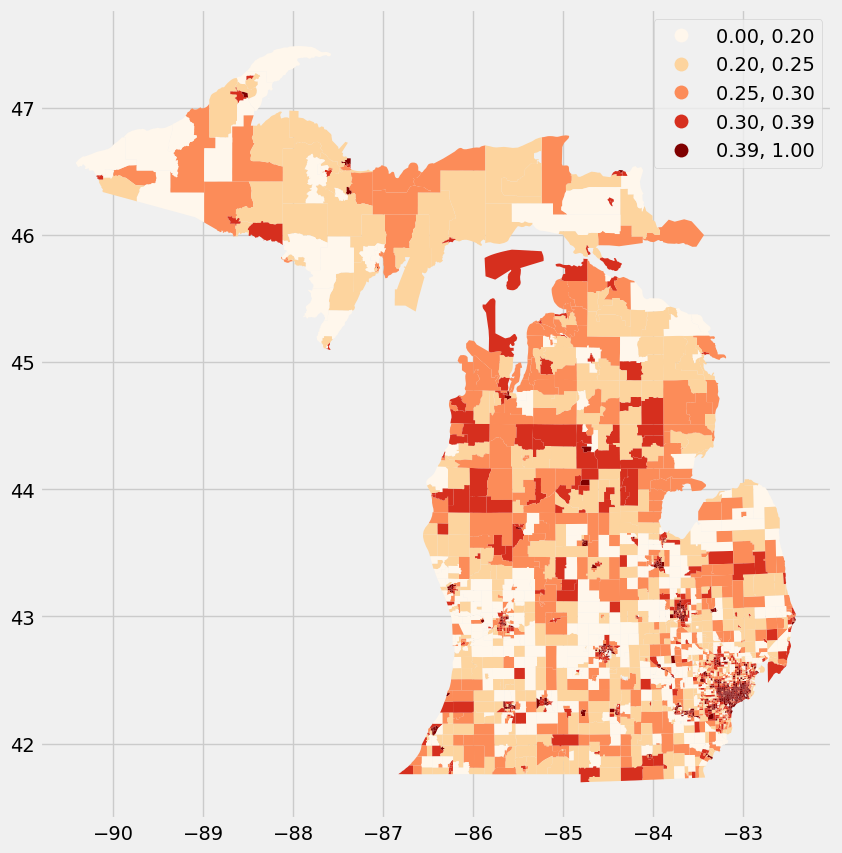

In [33]:
df_merged.plot(column='Housing Burdened', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

<Axes: >

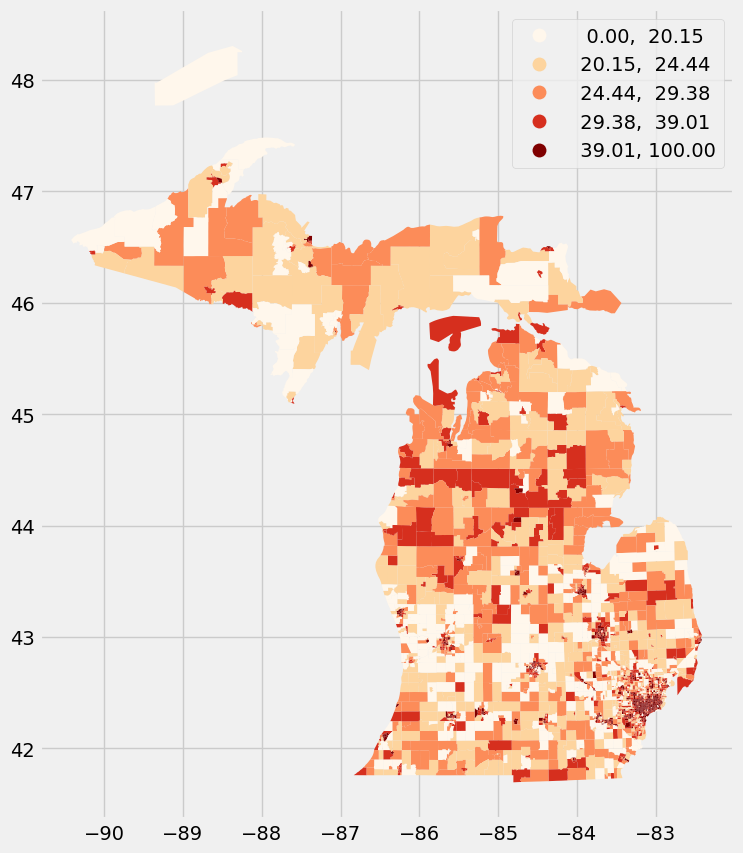

In [34]:
# There are a lot of missing values in the  above so I would make a map for the 'Housing Burdened 100%' column to see if there are differences.
df_merged.plot(column='Housing Burdened 100%', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

These maps show the distribution of households that are housing cost-burdened in Michigan (spending more than 30% of income on housing). Lighter areas indicate lower burden while darker reds indicate higher burden. Higher housing burden clusters appear most noticeably in parts of Southeast Michigan and parts of central Michigan (the middle). 

### Median Household Income

<Axes: >

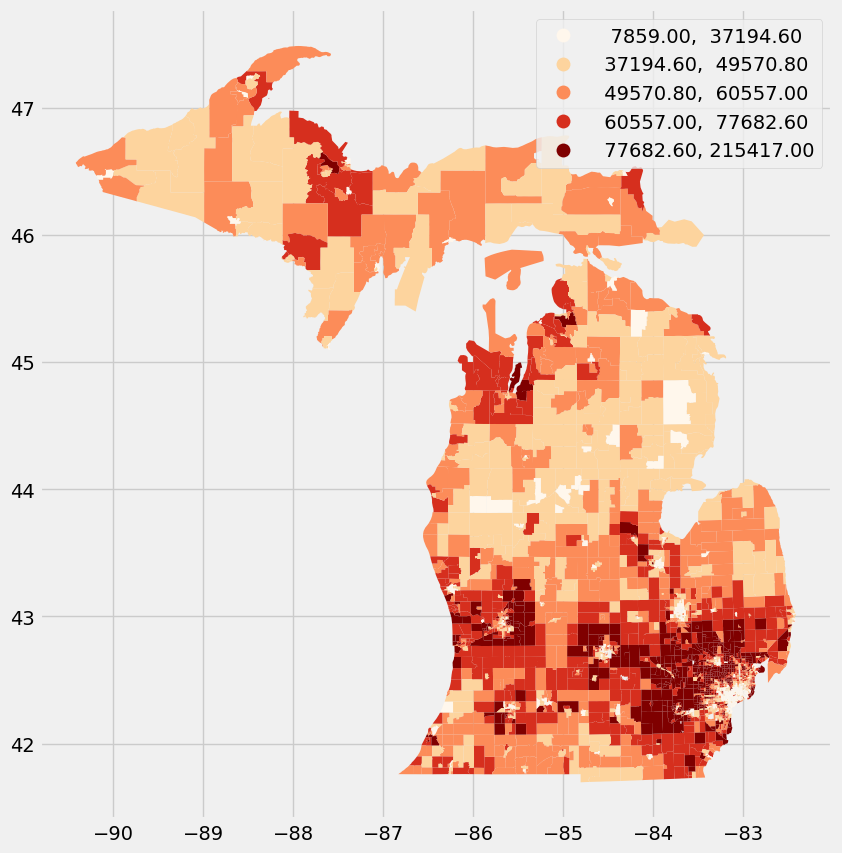

In [35]:
df_merged.plot(column='Median Household Income', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

This map shows median household income (inflation-adjusted) across Michigan, where lighter tracts represent lower incomes (about $7.9k–$37k) and darker reds represent higher incomes (about $77k–$215k). Higher-income clusters are most concentrated in Southeast Michigan while lower-income areas appear more frequently across parts of the Upper Peninsula. 

The above section provided an exploratory overview of the spatial distribution of multiple socioeconomic indicators across census tracts in Michigan.

In [20]:
#Need to confirm that this dataset is a geodataframe.
type (df_merged)

geopandas.geodataframe.GeoDataFrame

In [21]:
#Need to renamde it as gdf to make it easier to work with.
gdf = df_merged.copy()
type(gdf)

geopandas.geodataframe.GeoDataFrame

In [22]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   STATEFP10                2767 non-null   object  
 1   COUNTYFP10               2767 non-null   object  
 2   TRACTCE10                2767 non-null   object  
 3   GEOID                    2767 non-null   object  
 4   NAME10                   2767 non-null   object  
 5   NAMELSAD10               2767 non-null   object  
 6   MTFCC10                  2767 non-null   object  
 7   FUNCSTAT10               2767 non-null   object  
 8   ALAND10                  2767 non-null   int64   
 9   AWATER10                 2767 non-null   int64   
 10  INTPTLAT10               2767 non-null   object  
 11  INTPTLON10               2767 non-null   object  
 12  geometry                 2767 non-null   geometry
 13  County                   2767 non-null   object  
 14  

### PART B: ASTHMA PREVALENCE

In [23]:
# Need to load the asthma dataset.
import pandas as pd
df_asthma = pd.read_csv("Michigan_Asthma_Data.csv")
df_asthma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2745 entries, 0 to 2744
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   StateAbbr                2745 non-null   object 
 1   StateDesc                2745 non-null   object 
 2   CountyName               2745 non-null   object 
 3   CountyFIPS               2745 non-null   int64  
 4   GEOID                    2745 non-null   int64  
 5   TotalPopulation2020      2745 non-null   int64  
 6   CASTHMA_2020_CrudePrev   2745 non-null   float64
 7   CASTHMA_2020_Crude95CI   2745 non-null   object 
 8   CSMOKING_2020_CrudePrev  2745 non-null   float64
 9   CSMOKING_2020_Crude95CI  2745 non-null   object 
 10  Geolocation              2745 non-null   object 
 11  Unnamed: 11              0 non-null      float64
 12  TotalPopulation2021      2745 non-null   int64  
 13  CASTHMA_2021_CrudePrev   2745 non-null   float64
 14  CASTHMA_2021_Crude95CI  

In [24]:
df_asthma.columns

Index(['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'GEOID',
       'TotalPopulation2020', 'CASTHMA_2020_CrudePrev',
       'CASTHMA_2020_Crude95CI', 'CSMOKING_2020_CrudePrev',
       'CSMOKING_2020_Crude95CI', 'Geolocation', 'Unnamed: 11',
       'TotalPopulation2021', 'CASTHMA_2021_CrudePrev',
       'CASTHMA_2021_Crude95CI', 'CSMOKING_2021_CrudePrev',
       'CSMOKING_2021_Crude95CI', 'TotalPopulation2022',
       'CASTHMA_2022_CrudePrev', 'CASTHMA_2022_Crude95CI',
       'CSMOKING_2022_CrudePrev', 'CSMOKING_2022_Crude95CI',
       'TotalPopulation2023', 'CASTHMA_2023_CrudePrev',
       'CASTHMA_2023_Crude95CI', 'CSMOKING_2023_CrudePrev',
       'CSMOKING_2023_Crude95CI'],
      dtype='object')

In [25]:
#There are too many columns in the asthma dataset. I need to narrow down the columns to the ones that are relevant to my analysis.
df_asthma_trimmed = df_asthma[['CountyName','GEOID','CASTHMA_2020_CrudePrev','CASTHMA_2021_CrudePrev','CASTHMA_2022_CrudePrev', 'CASTHMA_2023_CrudePrev']]
df_asthma_trimmed.columns

Index(['CountyName', 'GEOID', 'CASTHMA_2020_CrudePrev',
       'CASTHMA_2021_CrudePrev', 'CASTHMA_2022_CrudePrev',
       'CASTHMA_2023_CrudePrev'],
      dtype='object')

In [26]:
#Rename columns in the dataset.
df_asthma_trimmed = df_asthma_trimmed.rename(columns={'CountyName': 'County', 'GEOID': 'GEOID', 'CASTHMA_2020_CrudePrev': 'Asthma_2020', 'CASTHMA_2021_CrudePrev': 'Asthma_2021', 'CASTHMA_2022_CrudePrev': 'Asthma_2022', 'CASTHMA_2023_CrudePrev': 'Asthma_2023'})
df_asthma_trimmed.columns

Index(['County', 'GEOID', 'Asthma_2020', 'Asthma_2021', 'Asthma_2022',
       'Asthma_2023'],
      dtype='object')

In [27]:
df_asthma_trimmed.describe()

,GEOID,Asthma_2020,Asthma_2021,Asthma_2022,Asthma_2023
count,2.745000e+03,2745.000000,2745.000000,2745.000000,2745.000000
mean,2.610886e+10,11.216576,11.294608,11.786485,11.534135
std,4.709454e+07,1.947258,1.772403,1.994355,1.670891
min,2.600100e+10,7.200000,7.700000,7.800000,8.100000
25%,2.607501e+10,10.000000,10.200000,10.500000,10.400000
50%,2.612100e+10,10.700000,10.800000,11.200000,11.000000
75%,2.616140e+10,11.800000,11.900000,12.400000,12.100000
max,2.616538e+10,19.700000,20.400000,20.500000,19.800000


The descriptive statistics show that asthma rates across Michigan census tracts were fairly stable over the four years. The average rates were 11.22 in 2020, 11.29 in 2021, 11.79 in 2022, and 11.53 in 2023, showing a rise through 2022 followed by a slight decline in 2023. The medians follow the same pattern. The standard deviations, ranging from about 1.67 to 1.99, indicate some variation across tracts, while the minimum and maximum values show that a few places consistently had much lower or much higher asthma rates than others.

### CHARTS

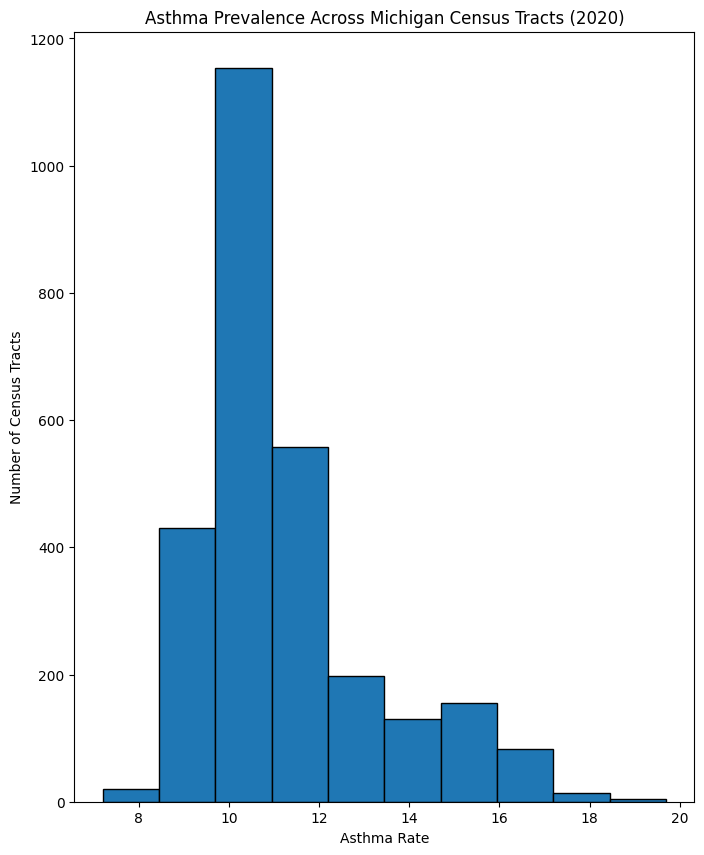

In [28]:
import matplotlib.pyplot as plt
df_asthma_trimmed['Asthma_2020'].plot(kind='hist', bins=10, edgecolor = 'black', title='Asthma Prevalence Across Michigan Census Tracts (2020)',xlabel ='Asthma Rate', ylabel = 'Number of Census Tracts', figsize = (8, 10))
plt.show()

The histogram shows that most Michigan census tracts in 2020 had asthma rates concentrated around 9 to 12, with the highest frequency near 10 to 11. The distribution is right-skewed, meaning there were fewer tracts with very high asthma rates, but a small number extended into the upper range. This suggests that moderate asthma prevalence was most common across the state, while only a limited number of tracts experienced notably higher rates.

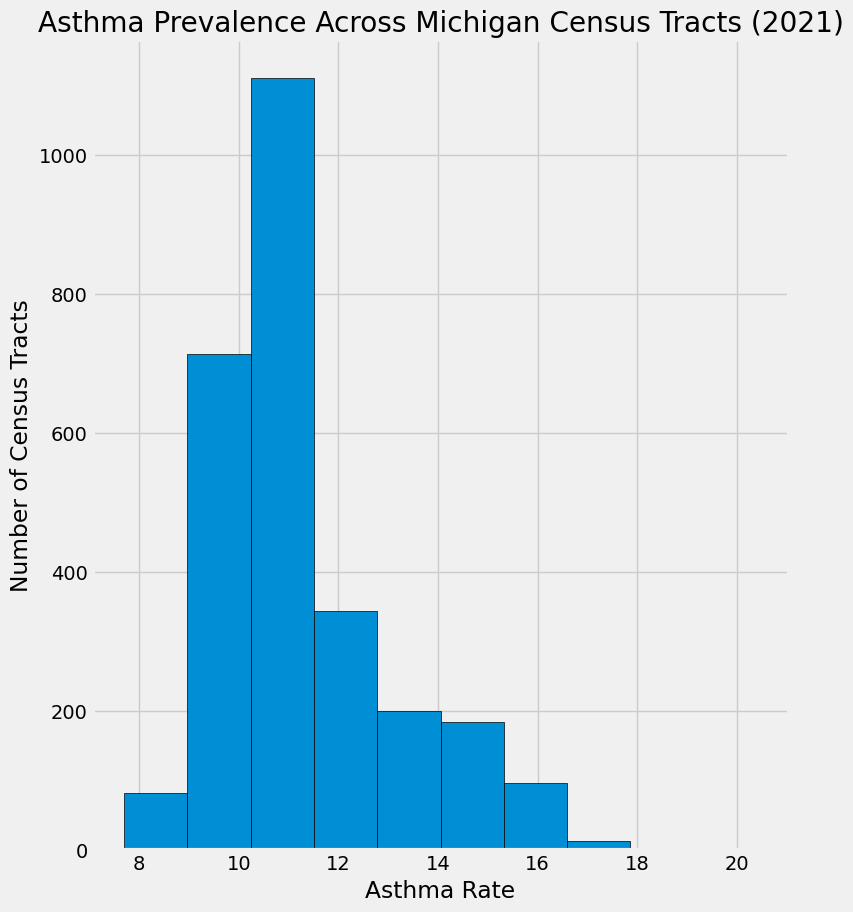

In [70]:
df_asthma_trimmed['Asthma_2021'].plot(kind='hist', bins=10, edgecolor = 'black', title='Asthma Prevalence Across Michigan Census Tracts (2021)',xlabel ='Asthma Rate', ylabel = 'Number of Census Tracts', figsize = (8, 10))
plt.show()

The 2021 histogram indicates that most Michigan census tracts had asthma rates concentrated between approximately 9 and 12, with the highest frequency around 10 to 11. Similar to 2020, the distribution is right-skewed, suggesting that while most tracts experienced moderate asthma rates, a smaller number recorded noticeably higher values.

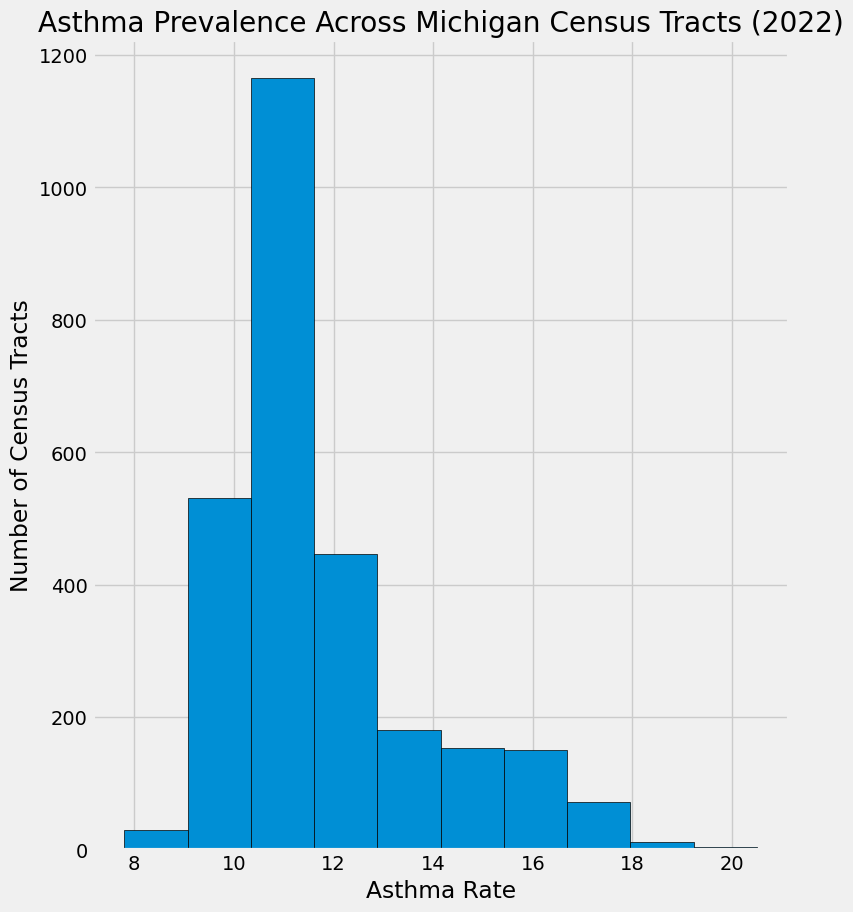

In [74]:
df_asthma_trimmed['Asthma_2022'].plot(kind='hist', bins=10, edgecolor = 'black', title='Asthma Prevalence Across Michigan Census Tracts (2022)',xlabel ='Asthma Rate', ylabel = 'Number of Census Tracts', figsize = (8, 10))
plt.show()

The histogram for 2022 shows that asthma rates were still concentrated in the 10 to 12 range across most Michigan census tracts, but the spread extends farther into the higher values than in earlier years. This suggests that while moderate asthma rates remained most common, more tracts experienced elevated rates in 2022.

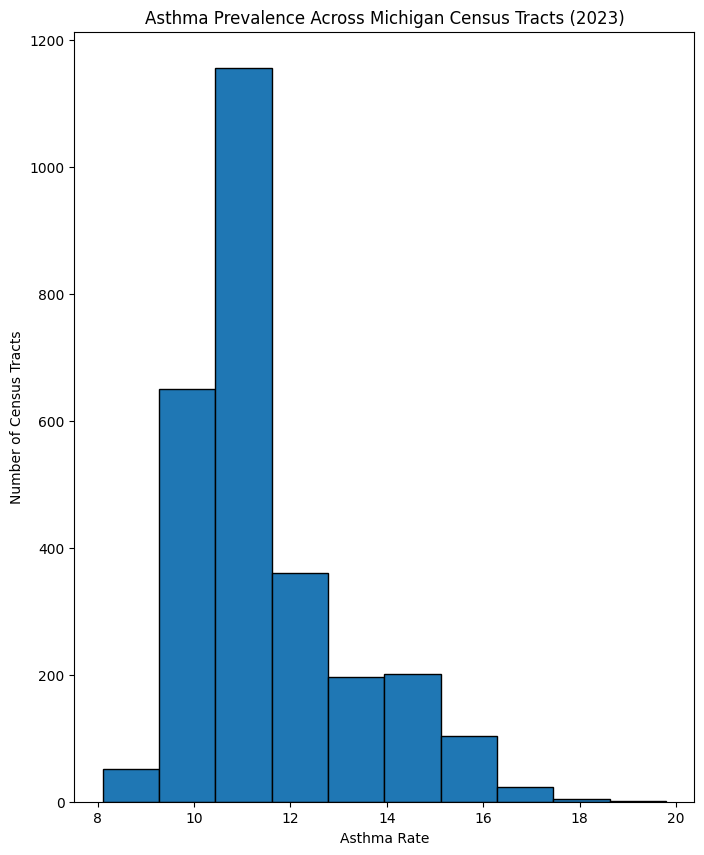

In [29]:
df_asthma_trimmed['Asthma_2023'].plot(kind='hist', bins=10, edgecolor = 'black', title='Asthma Prevalence Across Michigan Census Tracts (2023)',xlabel ='Asthma Rate', ylabel = 'Number of Census Tracts', figsize = (8, 10))
plt.show()

The 2023 histogram shows that asthma rates across Michigan census tracts were still centered mostly around 10 to 12, where the highest concentration of tracts appears. Compared with 2022, the upper tail looks a bit less extended, suggesting fewer tracts at the very highest asthma rates.

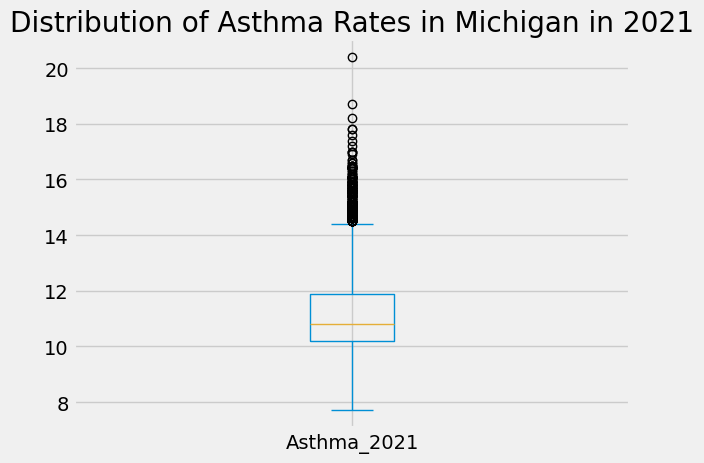

In [78]:
#Trying out Box Plots
df_asthma_trimmed['Asthma_2021'].plot(kind='box', title='Distribution of Asthma Rates in Michigan in 2021'
                                      )
plt.show()

The boxplot shows that most Michigan census tracts in 2021 had asthma rates clustered around the 10 to 12 range. The distribution is slightly right-skewed, as seen in the many high-value outliers above the upper whisker. This suggests that while most tracts had moderate asthma rates, a smaller number of tracts experienced much higher rates.

In [77]:
#Trying line graphs and bar graphs to see if I can get more insights from the data.

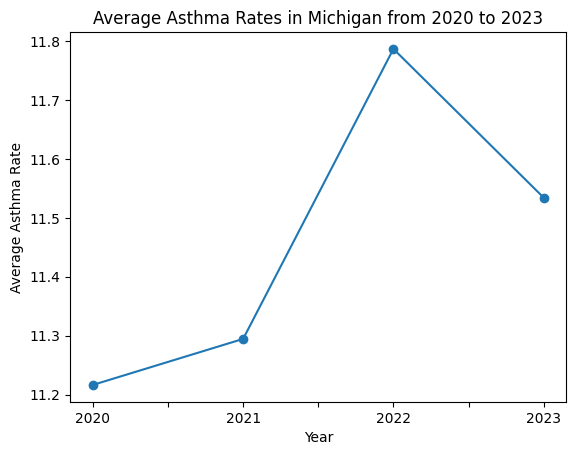

In [30]:
years = ['Asthma_2020', 'Asthma_2021', 'Asthma_2022', 'Asthma_2023']
avg_asthma_charts = df_asthma_trimmed[years].mean()
avg_asthma_charts.index = ['2020', '2021', '2022', '2023']
avg_asthma_charts.plot(kind='line', marker='o', title='Average Asthma Rates in Michigan from 2020 to 2023', xlabel = 'Year', ylabel = 'Average Asthma Rate')
plt.show()

 The line graph shows the overall trend in asthma rate in Michigan from 2020 to 2023. The graph indicates a slight increase from 2020 to 2021, a sharper rise to a peak in 2022, and then a moderate decline in 2023. Even with that decline, the 2023 rate was still higher than in 2020 and 2021.

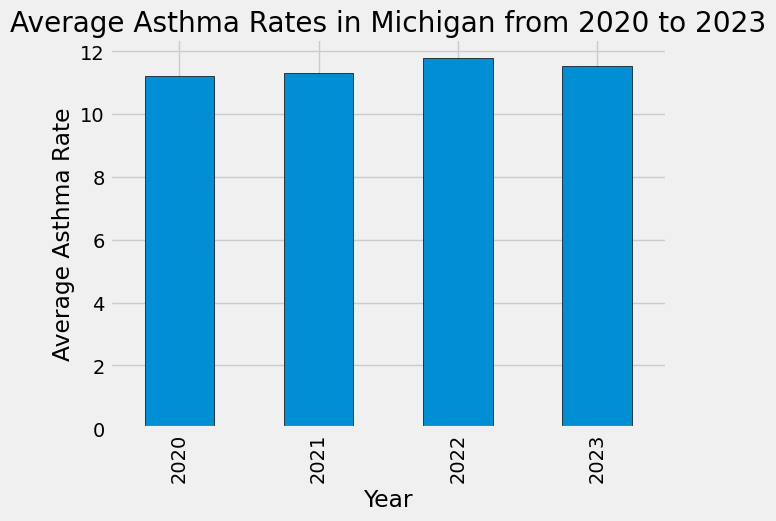

In [54]:
avg_asthma_charts.plot(kind='bar', title='Average Asthma Rates in Michigan from 2020 to 2023', edgecolor='black', xlabel = 'Year', ylabel = 'Average Asthma Rate')
plt.show()

Just like the line graph, the bar chart shows that average asthma rates in Michigan changed only slightly across the four years, with the highest value occurring in 2022. From the chart, rates increased from 2020 to 2022 before declining a little in 2023.

In [31]:
df_asthma_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2745 entries, 0 to 2744
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   County       2745 non-null   object 
 1   GEOID        2745 non-null   int64  
 2   Asthma_2020  2745 non-null   float64
 3   Asthma_2021  2745 non-null   float64
 4   Asthma_2022  2745 non-null   float64
 5   Asthma_2023  2745 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 128.8+ KB


In [32]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   STATEFP10                2767 non-null   object  
 1   COUNTYFP10               2767 non-null   object  
 2   TRACTCE10                2767 non-null   object  
 3   GEOID                    2767 non-null   object  
 4   NAME10                   2767 non-null   object  
 5   NAMELSAD10               2767 non-null   object  
 6   MTFCC10                  2767 non-null   object  
 7   FUNCSTAT10               2767 non-null   object  
 8   ALAND10                  2767 non-null   int64   
 9   AWATER10                 2767 non-null   int64   
 10  INTPTLAT10               2767 non-null   object  
 11  INTPTLON10               2767 non-null   object  
 12  geometry                 2767 non-null   geometry
 13  County                   2767 non-null   object  
 14  

In [33]:
# Let's change the integer GEOID column in df_asthma_trimmed to a string so that we can merge the two datasets.
df_asthma_format = df_asthma_trimmed.copy()
df_asthma_format['GEOID'] = df_asthma_format['GEOID'].astype(str)
df_asthma_format.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2745 entries, 0 to 2744
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   County       2745 non-null   object 
 1   GEOID        2745 non-null   object 
 2   Asthma_2020  2745 non-null   float64
 3   Asthma_2021  2745 non-null   float64
 4   Asthma_2022  2745 non-null   float64
 5   Asthma_2023  2745 non-null   float64
dtypes: float64(4), object(2)
memory usage: 128.8+ KB


In [34]:
#Do the join to merge this dataset with the gdf dataset.
gdf = gdf.merge(df_asthma_format, on = 'GEOID')
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2745 entries, 0 to 2744
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   STATEFP10                2745 non-null   object  
 1   COUNTYFP10               2745 non-null   object  
 2   TRACTCE10                2745 non-null   object  
 3   GEOID                    2745 non-null   object  
 4   NAME10                   2745 non-null   object  
 5   NAMELSAD10               2745 non-null   object  
 6   MTFCC10                  2745 non-null   object  
 7   FUNCSTAT10               2745 non-null   object  
 8   ALAND10                  2745 non-null   int64   
 9   AWATER10                 2745 non-null   int64   
 10  INTPTLAT10               2745 non-null   object  
 11  INTPTLON10               2745 non-null   object  
 12  geometry                 2745 non-null   geometry
 13  County_x                 2745 non-null   object  
 14  

In [35]:
gdf.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023'],
      dtype='object')

### MAPS

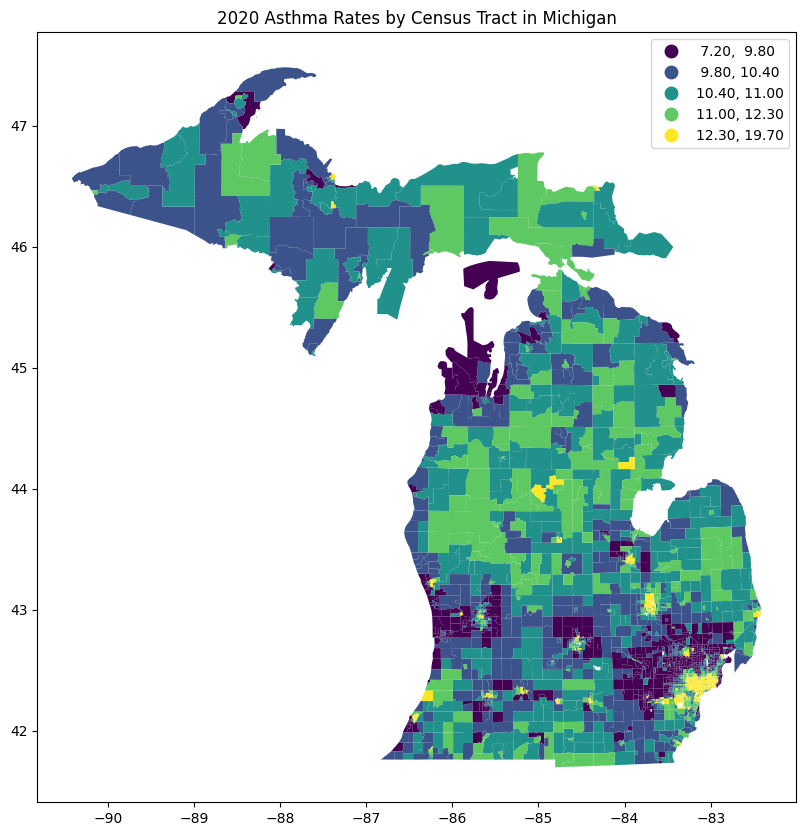

In [36]:
import matplotlib.pyplot as plt
import geopandas as gpd
ax = gdf.plot(column='Asthma_2020', cmap = 'viridis', scheme = 'quantiles', legend = True, figsize = (10, 10)) 
ax.set_title('2020 Asthma Rates by Census Tract in Michigan')
plt.show()

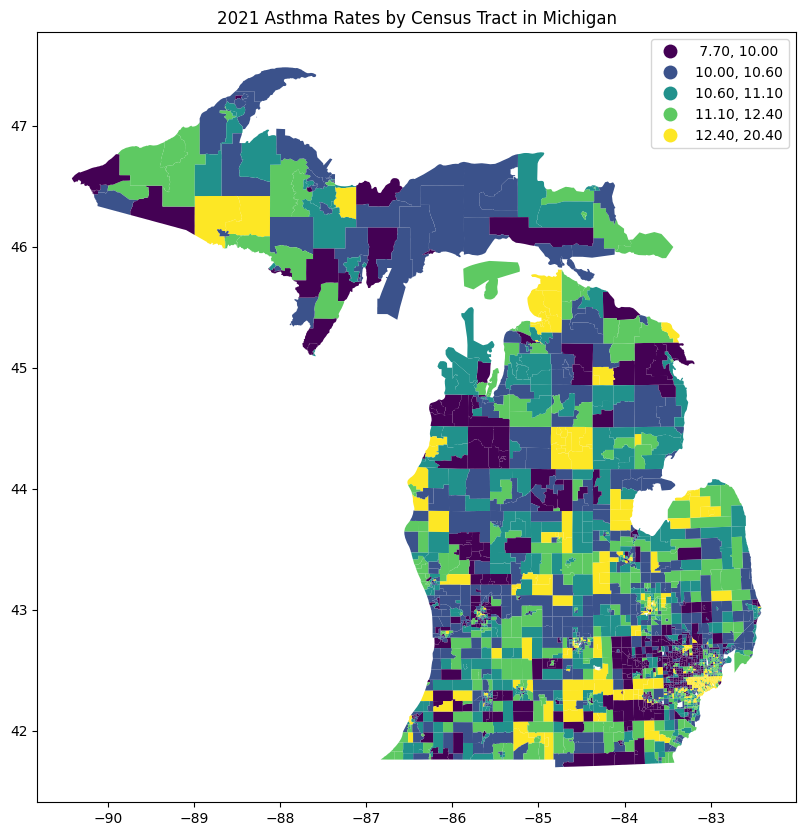

In [37]:
ax = gdf.plot(column='Asthma_2021', cmap = 'viridis', scheme = 'quantiles', legend = True, figsize = (10, 10)) 
ax.set_title('2021 Asthma Rates by Census Tract in Michigan')
plt.show()

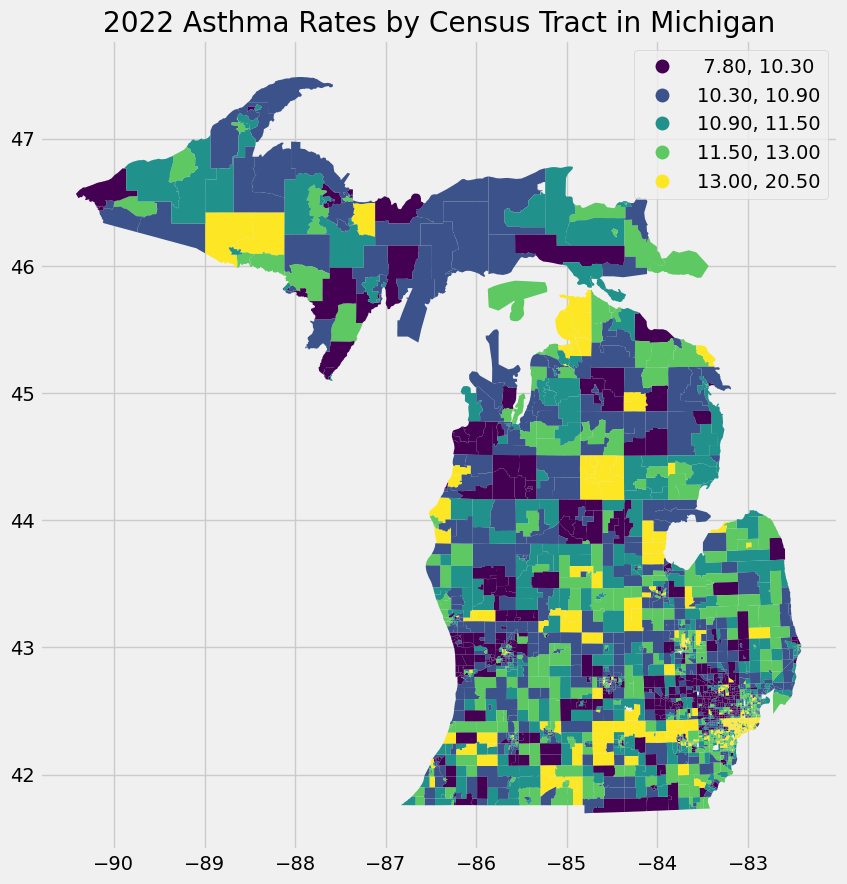

In [79]:
ax = gdf.plot(column='Asthma_2022', cmap = 'viridis', scheme = 'quantiles', legend = True, figsize = (10, 10)) 
ax.set_title('2022 Asthma Rates by Census Tract in Michigan')
plt.show()

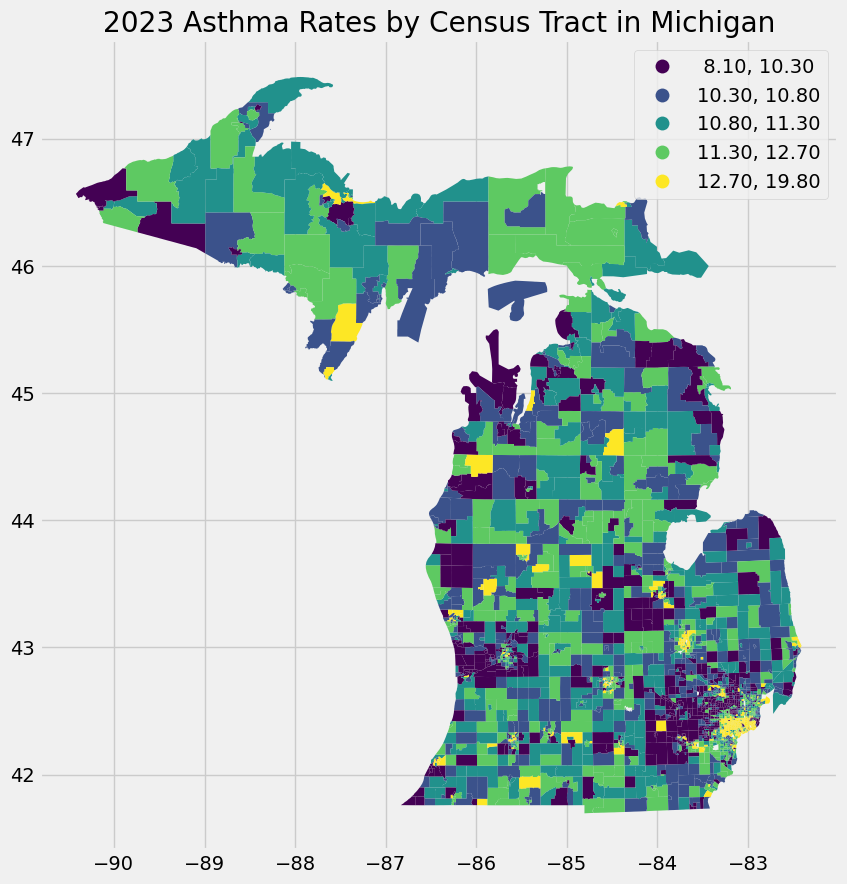

In [80]:
ax = gdf.plot(column='Asthma_2023', cmap = 'viridis', scheme = 'quantiles', legend = True, figsize = (10, 10)) 
ax.set_title('2023 Asthma Rates by Census Tract in Michigan')
plt.show()

The choropleth maps show that asthma rates across Michigan census tracts were not evenly distributed over the four years. In all years, lower asthma rates are represented by darker purple and blue tones, moderate rates appear in teal and green, and the highest rates are shown in yellow. This color progression makes it easier to distinguish areas with relatively low asthma prevalence from those with more elevated rates across the state.

From 2020 to 2023, the overall spatial pattern remains fairly consistent, though some changes in intensity are visible. In 2020, more tracts fall within the lower and middle rate categories, while 2021 and especially 2022 show a broader presence of green and yellow shades, indicating that more tracts shifted into higher asthma-rate classes during those years. By 2023, this intensity appears to decline slightly, with fewer strongly yellow areas than in 2022, although several higher-rate clusters remain visible. Overall, the maps suggest modest changes in asthma prevalence over time, with 2022 standing out as the year with the most pronounced concentration of higher-rate tracts.

### PART C: STATISTICAL ANALYSIS

##### AVERAGE ASTHMA RATE FOR EACH TRACT
For the statistical analysis, asthma prevalence values from 2020–2023 will be averaged to create a single asthma indicator for each census tract. Taking the average across the four years will help reduce short-term yearly fluctuations and provide a more stable estimate of asthma burden across tracts. The average will be calculated by computing the mean of the four annual asthma rates (2020, 2021, 2022, and 2023) for each census tract. This value will be used in the subsequent correlation and regression analyses.



In [38]:
gdf['asthma_avg'] = gdf[
    ['Asthma_2020','Asthma_2021','Asthma_2022','Asthma_2023']
].mean(axis=1)
gdf.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023', 'asthma_avg'],
      dtype='object')

In [39]:
gdf[['Asthma_2020','Asthma_2021','Asthma_2022','Asthma_2023','asthma_avg']].head(10)

,Asthma_2020,Asthma_2021,Asthma_2022,Asthma_2023,asthma_avg
0,10.2,11.2,11.5,11.4,11.075
1,9.7,10.7,11.1,11.7,10.800
2,9.4,11.4,11.8,10.0,10.650
3,9.6,11.1,11.5,10.7,10.725
4,9.5,10.8,11.2,10.3,10.450
5,10.6,10.9,11.1,10.6,10.800
6,11.0,10.9,11.1,10.3,10.825
7,10.4,10.9,11.1,10.7,10.775
8,10.6,10.9,11.6,11.0,11.025
9,10.6,11.3,12.0,11.3,11.300


##### SPEARMAN CORRELATION ANALYSIS
Spearman correlation analysis was used to examine the relationship between asthma prevalence and selected socioeconomic indicators. Each variable was tested individually to assess the strength of association with asthma outcomes across census tracts. Spearman Correlation was chosen for this analysis because it does not assume a normal distribution, making it suitable for socioeconomic and health data that do not follow normally distributed patterns.

In [91]:
correlation = gdf[['asthma_avg','Poverty Rate','Unemployment Rate','Housing Burdened', 'Median Household Income']].corr(method='spearman')
correlation

,asthma_avg,Poverty Rate,Unemployment Rate,Housing Burdened,Median Household Income
asthma_avg,1.000000,0.645990,0.591361,0.549661,-0.648639
Poverty Rate,0.645990,1.000000,0.701222,0.753695,-0.946485
Unemployment Rate,0.591361,0.701222,1.000000,0.567833,-0.706025
Housing Burdened,0.549661,0.753695,0.567833,1.000000,-0.759991
Median Household Income,-0.648639,-0.946485,-0.706025,-0.759991,1.000000


The Spearman correlation analysis shows that asthma prevalence across Michigan census tracts is closely related to socioeconomic conditions.  Asthma rates tend to be higher in tracts with greater disadvantage and lower in tracts with better socioeconomic conditions. This suggests that asthma is not randomly distributed, but instead follows broader social and economic inequalities.

Among the variables examined, poverty rate has the strongest positive relationship with asthma prevalence (r = 0.646). This indicates that tracts with higher poverty levels generally have higher asthma rates. One likely reason is that poverty is often linked to poor housing quality, greater exposure to indoor and neighborhood-level environmental hazards and limited access to healthcare and asthma management resources. In this way, poverty reflects a wider set of conditions that can increase both asthma risk and severity.

The unemployment rate also shows a positive association with asthma prevalence (r = 0.591). Tracts with higher unemployment tend to have worse asthma outcomes, possibly because unemployment reflects economic instability, stress and reduced access to health-supporting resources. Similarly, housing burden is positively correlated with asthma prevalence (r = 0.550), suggesting that areas where households spend a large share of income on housing also tend to experience higher asthma rates. This may be because cost-burdened households often have fewer resources for healthcare and may remain in lower-quality housing conditions that worsen respiratory health.

In contrast, median household income has a strong negative correlation with asthma prevalence (r = -0.649), meaning that tracts with higher income generally have lower asthma rates. Higher-income areas may benefit from better housing, lower exposure to environmental stressors and greater access to healthcare and preventive resources. This inverse relationship reinforces the broader pattern that economically advantaged communities tend to experience better health outcomes.

The socioeconomic variables are also strongly related to one another. Poverty is positively associated with unemployment and housing burden and strongly negatively associated with median household income. This suggests that asthma prevalence is influenced not by a single condition alone, but by overlapping forms of social and economic disadvantage operating together.

The results show meaningful associations, but they do not prove that these variables directly cause asthma differences across tracts. Still, the overall pattern is clear: asthma prevalence is higher in places facing greater socioeconomic vulnerability. This highlights the importance of addressing not only medical care, but also the broader social and economic conditions that shape asthma risk across Michigan.

#### MULTIPLE LINEAR REGRESSION
Multiple linear regression was used to examine the combined effect of several socioeconomic variables on asthma prevalence across Michigan census tracts. Unlike correlation, which looks at each variable separately, multiple regression makes it possible to assess how poverty rate, unemployment rate, housing burden and median household income jointly relate to asthma outcomes in the same model. This is important because these variables are often interconnected and regression helps show the unique contribution of each predictor while controlling for the others. As a result, the method provides a clearer understanding of which socioeconomic factors remain important predictors of asthma prevalence when their shared influence is taken into account.

In [92]:
# For this, I need to install statsmodels.
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.7 MB/s eta 0:00:06
   ------------ --------------------------- 2.9/9.5 MB 6.8 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 7.4 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 8.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [stats


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
# Please Note:I used this model as an introductory way to test whether poverty rate, unemployment rate, housing burden and median household income jointly influence asthma prevalence. In the code, y represents the outcome variable (asthma prevalence), while X contains the socioeconomic predictors. The model then estimates how each predictor relates to asthma while accounting for the others. VS Code made it really easy as it gave me suggestions for the code and I was able to run the model and get the summary output.
import statsmodels.api as sm
df_reg = gdf[['asthma_avg', 'Poverty Rate', 'Unemployment Rate', 'Housing Burdened', 'Median Household Income']].copy()

# Drop rows with missing values
df_reg = df_reg.dropna()

# Define y and X
y = df_reg['asthma_avg']
X = df_reg[['Poverty Rate', 'Unemployment Rate', 'Housing Burdened', 'Median Household Income']]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit() 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             asthma_avg   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     850.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:41:23   Log-Likelihood:                -3950.7
No. Observations:                2726   AIC:                             7911.
Df Residuals:                    2721   BIC:                             7941.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

The multiple linear regression results show that the socioeconomic variables jointly explain a substantial share of the variation in asthma prevalence across Michigan census tracts. The model is statistically significant overall (F = 850.2, p < 0.001), and the R² of 0.556 indicates that about 55.6% of the variation in average asthma prevalence is explained by poverty rate, unemployment rate, housing burden and median household income together.
The regression table shows that poverty rate (coef = 0.0154, p < 0.001), unemployment rate (coef = 0.0813, p < 0.001) and housing burden (coef = 1.8957, p < 0.001) all have positive and statistically significant relationships with asthma prevalence.This means that, holding the other variables constant, census tracts with higher poverty, higher unemployment and greater housing burden tend to have higher asthma rates. Median household income has a negative coefficient and is also statistically significant, though only marginally (p = 0.049), suggesting that tracts with higher income tend to have slightly lower asthma prevalence when the other factors are taken into account.

Looking at the t-values, unemployment rate stands out most strongly in the model, suggesting it has the clearest positive association with asthma prevalence after accounting for the other variables. Housing burden also shows a positive association, as indicated by its positive coefficient and statistically significant t-value. Overall, the regression analysis reinforces that asthma outcomes are shaped by broader socioeconomic disadvantage. Thus, tracts facing more economic hardship tend to experience worse asthma outcomes.



### DUAL BURDEN ANALYSIS
 A dual burden analysis was used to identify census tracts where high asthma prevalence overlaps with high socioeconomic vulnerability. High-risk thresholds were defined using the 75th percentile (top 25% of values). This threshold was selected because it captures areas with relatively elevated asthma prevalence and socioeconomic disadvantage. Dual burden maps were then created to identify tracts where both high asthma rates and high socioeconomic vulnerability occur simultaneously.

In [40]:
analysis_df =gdf.copy()
analysis_df.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023', 'asthma_avg'],
      dtype='object')

Defining the High Risk Indicators

In [41]:
#For median household income, the lowest 25% of values are used to identify vulnerable tracts, since lower income levels indicate greater socioeconomic disadvantage.
analysis_df['high_asthma'] = analysis_df['asthma_avg'] > analysis_df['asthma_avg'].quantile(0.75)
analysis_df['high_poverty'] = analysis_df['Poverty Rate'] > analysis_df['Poverty Rate'].quantile(0.75)
analysis_df['high_unemployment'] = analysis_df['Unemployment Rate'] > analysis_df['Unemployment Rate'].quantile(0.75)
analysis_df['high_housingburden'] = analysis_df['Housing Burdened'] > analysis_df['Housing Burdened'].quantile(0.75)
analysis_df['low_income'] = analysis_df['Median Household Income'] < analysis_df['Median Household Income'].quantile(0.25)

In [42]:
analysis_df.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,...,Asthma_2020,Asthma_2021,Asthma_2022,Asthma_2023,asthma_avg,high_asthma,high_poverty,high_unemployment,high_housingburden,low_income
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,...,10.2,11.2,11.5,11.4,11.075,False,False,False,False,False
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,...,9.7,10.7,11.1,11.7,10.800,False,False,False,False,False
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,...,9.4,11.4,11.8,10.0,10.650,False,False,False,False,False
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,...,9.6,11.1,11.5,10.7,10.725,False,False,False,False,False
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,...,9.5,10.8,11.2,10.3,10.450,False,False,False,False,False


Creating the dual burden variables by combining the high asthma and high socioeconomic indicators. 

In [43]:
analysis_df['dualburden_poverty'] = (
    analysis_df['high_asthma'] & analysis_df['high_poverty']
)

In [44]:
analysis_df['dualburden_unemployment'] = (
    analysis_df['high_asthma'] & analysis_df['high_unemployment']
)

In [45]:
analysis_df['dualburden_housingburden'] = (
    analysis_df['high_asthma'] & analysis_df['high_housingburden']
)

In [46]:
analysis_df['dualburden_low_income'] = (
    analysis_df['high_asthma'] & analysis_df['low_income']
)

In [47]:
analysis_df.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,...,asthma_avg,high_asthma,high_poverty,high_unemployment,high_housingburden,low_income,dualburden_poverty,dualburden_unemployment,dualburden_housingburden,dualburden_low_income
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,...,11.075,False,False,False,False,False,False,False,False,False
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,...,10.800,False,False,False,False,False,False,False,False,False
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,...,10.650,False,False,False,False,False,False,False,False,False
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,...,10.725,False,False,False,False,False,False,False,False,False
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,...,10.450,False,False,False,False,False,False,False,False,False


DUAL BURDEN: POVERTY & ASTHMA

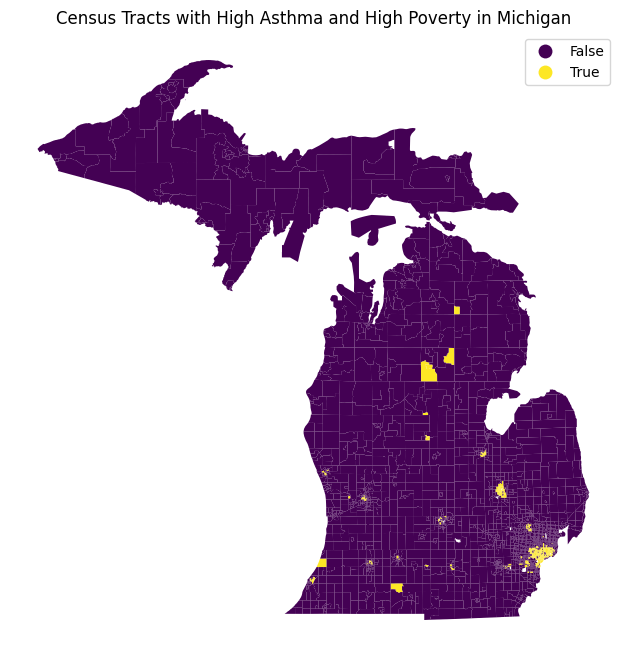

In [48]:
import matplotlib.pyplot as plt

analysis_df.plot(
    column='dualburden_poverty',
    legend=True,
    figsize=(8,8),
    cmap='viridis',
)

plt.title("Census Tracts with High Asthma and High Poverty in Michigan")
plt.axis('off')
plt.show()

In [49]:
analysis_df['dualburden_poverty'].sum()

np.int64(444)

This map shows the Michigan census tracts where high asthma prevalence and high poverty overlap. In total, 444 tracts met both conditions, and these are concentrated in a few parts of the state rather than being evenly spread across Michigan. The clearest cluster appears in southeastern Michigan, with a smaller number of scattered tracts elsewhere in the state.

DUAL BURDEN: UNEMPLOYMENT & ASTHMA

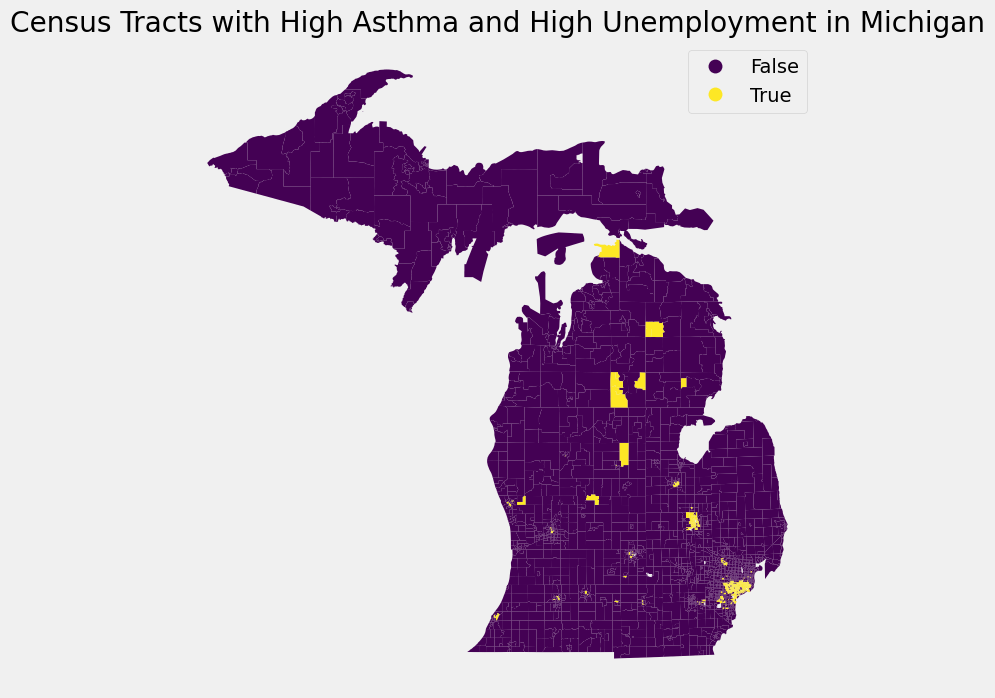

In [141]:
analysis_df.plot(
    column='dualburden_unemployment',
    legend=True,
    figsize=(8,8),
    cmap='viridis',
)

plt.title("Census Tracts with High Asthma and High Unemployment in Michigan")
plt.axis('off')
plt.show()

In [142]:
analysis_df['dualburden_unemployment'].sum()

np.int64(455)

This map shows the Michigan census tracts where high asthma prevalence and high unemployment overlap. In total, 455 tracts met both conditions. The highlighted tracts are clustered most clearly in southeastern Michigan, with a few additional pockets in other areas.

DUAL BURDEN: HIGH HOUSING BURDEN & ASTHMA

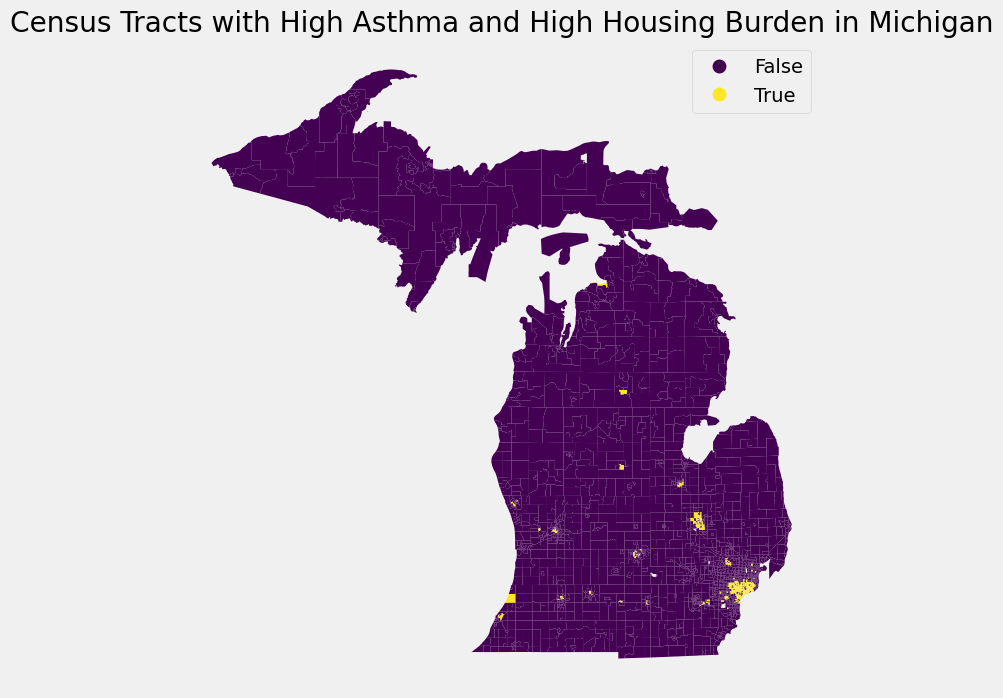

In [144]:
analysis_df.plot(
    column='dualburden_housingburden',
    legend=True,
    figsize=(8,8),
    cmap='viridis',
)

plt.title("Census Tracts with High Asthma and High Housing Burden in Michigan")
plt.axis('off')
plt.show()

In [145]:
analysis_df['dualburden_housingburden'].sum()

np.int64(429)

This map identifies Michigan census tracts where high asthma prevalence overlaps with high housing cost burden. A total of 429 tracts met both conditions, indicating that this combined burden affects a relatively small but notable portion of the state. These tracts are most heavily concentrated in southeastern Michigan, with smaller pockets appearing in other regions. 

DUAL BURDEN: LOW INCOME & ASTHMA

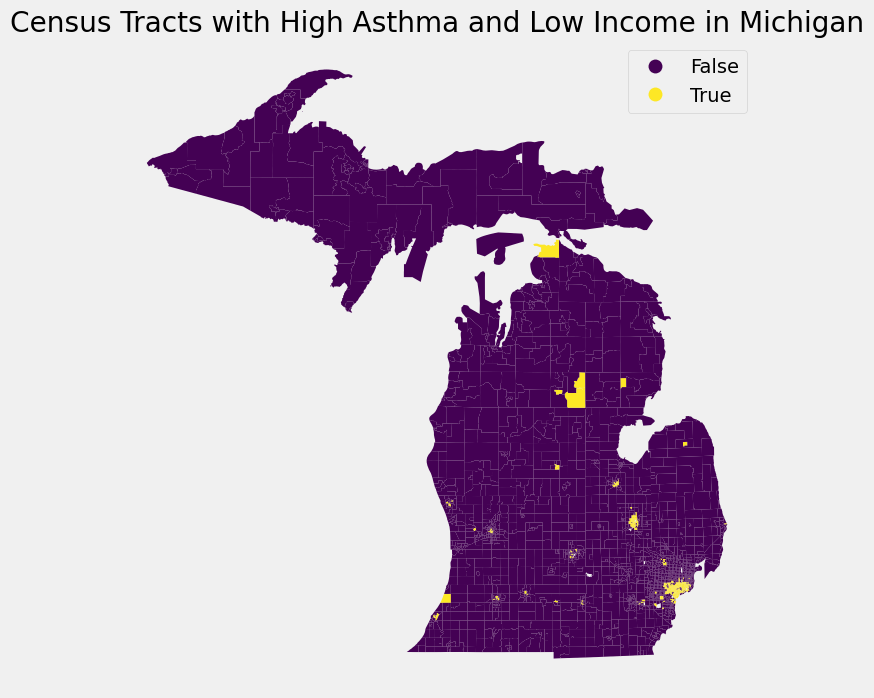

In [146]:
analysis_df.plot(
    column='dualburden_low_income',
    legend=True,
    figsize=(8,8),
    cmap='viridis',
)

plt.title("Census Tracts with High Asthma and Low Income in Michigan")
plt.axis('off')
plt.show()

In [50]:
analysis_df['dualburden_low_income'].sum()

np.int64(428)

This map identifies Michigan census tracts where high asthma prevalence overlaps with low income. In total, 428 tracts met both conditions, indicating that this combined burden affects a relatively small share of tracts across the state. Just like the other socioeconomic variables, the highlighted tracts are most strongly concentrated in southeastern Michigan, with smaller clusters appearing in other regions.

OVERALL VULNERABILITY SCORE

In [51]:
analysis_df.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023', 'asthma_avg', 'high_asthma',
       'high_poverty', 'high_unemployment', 'high_housingburden', 'low_income',
       'dualburden_poverty', 'dualburden_unemployment',
       'dualburden_housingburden', 'dualburden_low_income'],
      dtype='object')

In [52]:
analysis_df['vulnerability_score'] = (
    analysis_df['high_poverty'].astype(int) +
    analysis_df['high_unemployment'].astype(int) +
    analysis_df['high_housingburden'].astype(int)+
    analysis_df['low_income'].astype(int)
)

In [53]:
analysis_df[analysis_df['vulnerability_score'] >= 2].head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,...,high_asthma,high_poverty,high_unemployment,high_housingburden,low_income,dualburden_poverty,dualburden_unemployment,dualburden_housingburden,dualburden_low_income,vulnerability_score
12,26,163,571500,26163571500,5715,Census Tract 5715,G5020,S,3140755,22246,...,True,False,False,True,True,False,False,True,True,2
14,26,163,570900,26163570900,5709,Census Tract 5709,G5020,S,1444060,0,...,True,True,True,False,True,True,True,False,True,3
15,26,163,570200,26163570200,5702,Census Tract 5702,G5020,S,1807948,1610,...,True,True,True,True,True,True,True,True,True,4
27,26,163,524800,26163524800,5248,Census Tract 5248,G5020,S,1118325,0,...,True,True,True,True,True,True,True,True,True,4
36,26,163,521900,26163521900,5219,Census Tract 5219,G5020,S,1692449,0,...,True,True,True,True,True,True,True,True,True,4


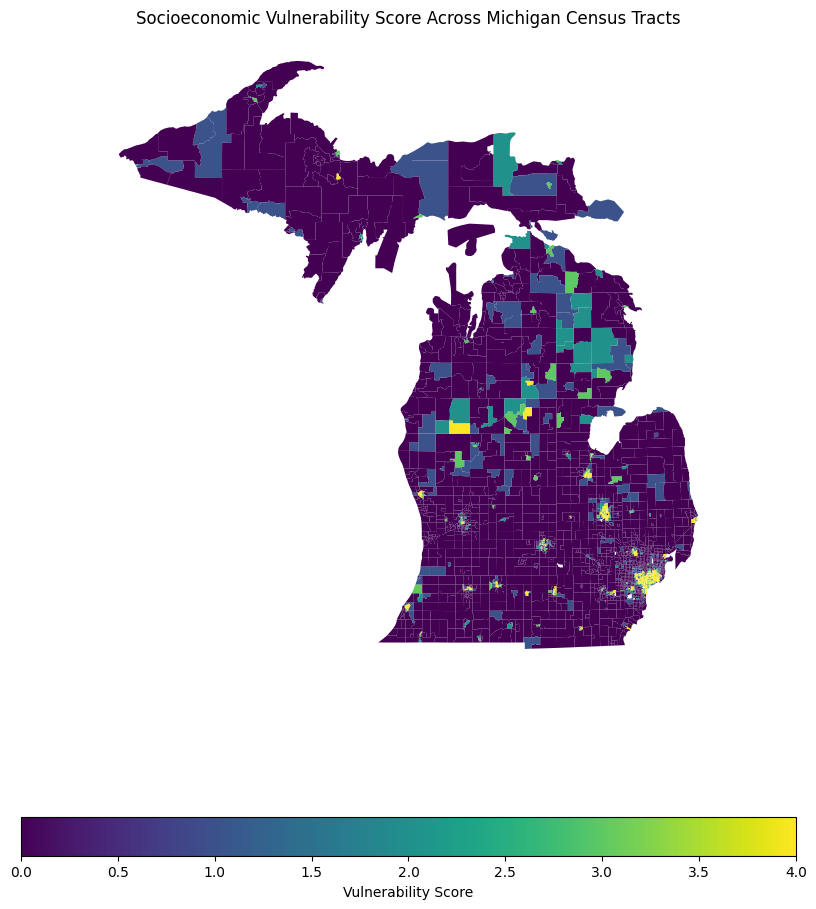

In [54]:
analysis_df.plot(
    column='vulnerability_score',
    legend=True,
    figsize=(10,12),
    cmap='viridis',
    legend_kwds={
    'label': 'Vulnerability Score',
    'orientation': 'horizontal'
}
)

plt.title("Socioeconomic Vulnerability Score Across Michigan Census Tracts")
plt.axis('off')
plt.show()

This map shows a clear spatial pattern in socioeconomic vulnerability across Michigan census tracts. Lower vulnerability scores, shown in darker purple tones, dominate much of the state, while higher scores, shown in green to yellow, are concentrated in more limited areas. The most noticeable cluster of high vulnerability appears in southeastern Michigan, with a few additional scattered tracts in parts of central and northern Michigan. The pattern suggests that socioeconomic disadvantage is not evenly distributed, but is concentrated in specific communities facing multiple overlapping challenges.

FINAL GEODATAFRAME

In [55]:
gdf.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023', 'asthma_avg'],
      dtype='object')

In [56]:
analysis_df.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023', 'asthma_avg', 'high_asthma',
       'high_poverty', 'high_unemployment', 'high_housingburden', 'low_income',
       'dualburden_poverty', 'dualburden_unemployment',
       'dualburden_housingburden', 'dualburden_low_income',
       'vulnerability_score'],
      dtype='object')

In [57]:
#Selecting the new analysis variables.
analysis_cols = analysis_df[['GEOID',
                             'dualburden_poverty',
                             'dualburden_unemployment',
                             'dualburden_housingburden',
                             'dualburden_low_income',
                             'vulnerability_score']]
analysis_cols.columns

Index(['GEOID', 'dualburden_poverty', 'dualburden_unemployment',
       'dualburden_housingburden', 'dualburden_low_income',
       'vulnerability_score'],
      dtype='object')

In [58]:
#Joining to the original geodataframe.
gdf = gdf.merge(analysis_cols, on = 'GEOID', how = 'left')
gdf.columns

Index(['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID', 'NAME10', 'NAMELSAD10',
       'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'County_x', 'Poverty Rate',
       'Unemployment Rate', 'Housing Burdened', 'Housing Burdened 100%',
       'Median Household Income', 'County_y', 'Asthma_2020', 'Asthma_2021',
       'Asthma_2022', 'Asthma_2023', 'asthma_avg', 'dualburden_poverty',
       'dualburden_unemployment', 'dualburden_housingburden',
       'dualburden_low_income', 'vulnerability_score'],
      dtype='object')

In [59]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

In [60]:
gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [62]:
print(gdf.geometry)


0       POLYGON ((-84.27849 43.60846, -84.27839 43.607...
1       POLYGON ((-84.20713 43.61134, -84.20744 43.611...
2       POLYGON ((-84.19284 43.64106, -84.18922 43.641...
3       POLYGON ((-84.20688 43.65404, -84.20431 43.652...
4       POLYGON ((-84.28999 43.65613, -84.28452 43.656...
                              ...                        
2740    POLYGON ((-83.69748 42.16381, -83.69762 42.167...
2741    POLYGON ((-83.66238 42.35533, -83.6624 42.3563...
2742    POLYGON ((-83.81413 42.3414, -83.81475 42.3413...
2743    POLYGON ((-83.59079 42.27588, -83.58833 42.275...
2744    POLYGON ((-85.00071 44.85893, -84.99969 44.858...
Name: geometry, Length: 2745, dtype: geometry


In [63]:
print(gdf.crs)

EPSG:4269


In [65]:
gdf = gdf.to_crs(epsg=4326)

In [66]:
print(gdf.geometry.head())

0    POLYGON ((-84.27849 43.60846, -84.27839 43.607...
1    POLYGON ((-84.20713 43.61134, -84.20744 43.611...
2    POLYGON ((-84.19284 43.64106, -84.18922 43.641...
3    POLYGON ((-84.20688 43.65404, -84.20431 43.652...
4    POLYGON ((-84.28999 43.65613, -84.28452 43.656...
Name: geometry, dtype: geometry


In [84]:
#Saving the geodataframe as a geojson file so that I can upload it to ArcGIS Online and create a web map.
gdf.to_file("newmichigan_asthma_vulnerability_V22.geojson", driver="GeoJSON")

<Axes: >

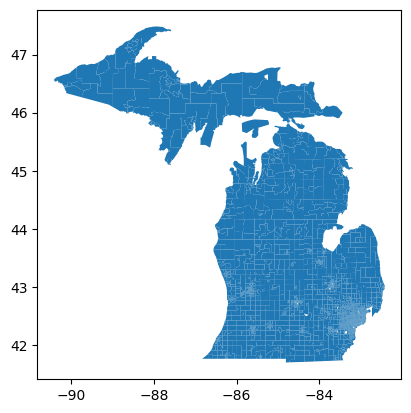

In [69]:
#checking to see if it will work in agol
gdf.plot()

In [70]:
from arcgis.gis import GIS
def agol_login():
    import getpass
    print("Portal for ArcGIS as a built in user")
    pwd = getpass.getpass('PASSWORD: ')
    username = getpass.getpass('USERNAME: ')
    gis = GIS("https://wmugeography.maps.arcgis.com",username, pwd)
    print("Logged in as: " + gis.properties.user.username)
    return gis

In [71]:
gis = agol_login()

Portal for ArcGIS as a built in user
Logged in as: T_AttomWMU25


In [72]:
print(gis.users.me)

<User username:T_AttomWMU25>


In [ ]:
#Publishing to ArcGIS Online
from arcgis.gis import GIS

item_properties = {
    "title": "Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan",
    "type": "GeoJson",
    "tags": "GEOG 6670"
}

newgeojson_item = gis.content.add(
    item_properties=item_properties,
    data="newmichigan_asthma_vulnerability_V22.geojson"
)
new_service = newgeojson_item.publish()
new_service


c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3701: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


<Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:Feature Layer Collection owner:T_AttomWMU25>

In [86]:
print (gis.users.me)

<User username:T_AttomWMU25>


In [87]:
#Locating the GeoJSON file that I just uploaded to ArcGIS Online.
items = gis.content.search("Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan")
items

[<Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:Web Map owner:T_AttomWMU25>,
 <Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:GeoJson owner:T_AttomWMU25>,
 <Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:Feature Layer Collection owner:T_AttomWMU25>]

To make the webmap, I need to install arcgis-mapping

In [194]:
!pip install arcgis-mapping

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 1.3 MB/s eta 0:00:06
   ---- ----------------------------------- 0.8/7.8 MB 1.2 MB/s eta 0:00:07
   ---- ----------------------------------- 0.8/7.8 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/7.8 MB 1.0 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/7.8 MB 930.7 kB/s eta 0:00:07
   -------- ------------------------------- 1.6/7.8 MB 952.3 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/7.8 MB 977.3 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/7.8 MB 977.3 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/7.8 MB 1.0 MB/s eta 0:00:06
   ------------ --------------------------- 2.4/7.8 MB 977.0 kB/s eta 0:00:06
   ------------- ------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  res = process_handler(cmd, _system_body)
c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)
c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)


In [88]:
!pip show arcgis-mapping

Name: arcgis-mapping
Version: 4.33.1
Summary: Leverage Python for ArcGIS! This package provides classes for building both interactive 2D maps and immersive 3D scenes.
Home-page: 
Author: 
Author-email: ArcGIS API for Python Team <support@esri.com>
License: Esri Master License Agreement
Location: c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages
Requires: anywidget, arcgis, ipywidgets, jupyterlab, pandas, pydantic
Required-by: 


c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=10>
  res = process_handler(cmd, _system_body)
c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=11>
  res = process_handler(cmd, _system_body)
c:\Users\Administrator\Desktop\VSCODE\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=12>
  res = process_handler(cmd, _system_body)


In [90]:
import arcgis.mapping
from arcgis.mapping import WebMap

ModuleNotFoundError: No module named 'arcgis.mapping'

Please Note: The arcgis.mapping module was not working, so I searched online and found an alternative: arcgis.map. After switching to arcgis.map instead of arcgis.mapping, the code worked.(The source stated a recent ArcGIS API for Python update may have replaced arcgis.mapping with arcgis.map, with WebMap() replaced by Map().I am not completely certain that this was the cause of the issue (maybe the version of python I have installed), but it appears to have resolved the problem.)

In [91]:
#Try of the arcgis.map
import arcgis
from arcgis.map import Map
m = Map("Michigan")
m

Map()

In [93]:
items = gis.content.search("Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan")
items

[<Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:GeoJson owner:T_AttomWMU25>,
 <Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:Feature Layer Collection owner:T_AttomWMU25>]

In [94]:
feature_layer_item = [items[1]]
feature_layer_item

[<Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:Feature Layer Collection owner:T_AttomWMU25>]

In [96]:
from arcgis.map import Map
webmap = Map()
webmap

Map()

In [98]:
# Need to add the feature layer to the webmap.
webmap.content.add(feature_layer_item, options={"title": "Michigan Asthma and Socioeconomic Vulnerability"})
webmap

Map()

In [99]:
#it worked
webmap.content.layers

[<FeatureLayer url:"https://services1.arcgis.com/vFQXQuqACTPxa4Yc/arcgis/rest/services/Spatial_Analysis_of_Asthma_and_Socioeconomic_Vulnerability_in_Michigan/FeatureServer/0">,
 GroupLayer(title=Michigan Asthma and Socioeconomic Vulnerability)]

In [100]:
webmap_properties = {
    "title": "Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan",
    "snippet": "Census tract analysis of asthma prevalence and socioeconomic conditions",
    "tags": ["GEOG 6670"]
}

webmap_item = webmap.save(webmap_properties)
webmap_item

<Item title:"Spatial Analysis of Asthma and Socioeconomic Vulnerability in Michigan" type:Web Map owner:T_AttomWMU25>

Now we have our webmap

### SUMMARY
This project examined how asthma prevalence varies across Michigan census tracts and how those patterns relate to socioeconomic disadvantage. The results show that asthma rates changed only modestly from 2020 to 2023, with 2022 standing out as the year with the highest average prevalence. The choropleth maps and histogram further showed that asthma is not evenly distributed across the state, but is concentrated in specific areas, especially parts of southeastern Michigan. 
The statistical analyses reinforced this pattern. Spearman correlation results showed that asthma prevalence was positively associated with poverty, unemployment and housing burden, and negatively associated with median household income. The multiple linear regression model confirmed that these factors jointly matter, explaining about 55.6% of the variation in asthma prevalence across census tracts. Higher poverty, higher unemployment and greater housing burden were linked to higher asthma rates, while higher income was associated with slightly lower asthma prevalence.

The dual burden maps provided additional spatial evidence of this relationship by showing where high asthma overlaps with high poverty, high unemployment, high housing burden and low income. These overlaps were not spread evenly across Michigan, but were concentrated in a limited number of tracts, again with the clearest clustering in southeastern Michigan. The socioeconomic vulnerability map also highlighted that broader disadvantage is concentrated in some communities rather than across the entire state.

Overall, the project shows that asthma disparities in Michigan are closely tied to neighborhood-level socioeconomic inequality. This suggests that asthma prevalence in Michigan are shaped not only by environmental factors but also by the broader social and economic conditions in which people live.